<a href="https://colab.research.google.com/github/jordi-cx/it_academy/blob/main/sprint_08_jcx_wip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1.1: Exploración del dataset

A partir de un fichero de Excel, vamos a explorar las características que presentan los datos. Debemos crear el dataframe y responder a las siguientes cuestiones:

- Dimensión del dataset
- Ver muestra de filas
- Tipos de variables por columnas
- Coherencia de los datos
- Detectar duplicados
- Detectar problemas e inconsistencias



In [2]:
# Importar el dataset
fichero_empleados = "empleats_enquesta.xlsx"

df_empleados = pd.read_excel(fichero_empleados, sheet_name='sprint10_complex', header=3, index_col=0).sort_index()
# display(df_empleados)

In [3]:
# Dimensión del dataset
print(f"El dataset tiene {df_empleados.shape[0]} filas y {df_empleados.shape[1]} columnas.")

El dataset tiene 1007 filas y 19 columnas.


In [4]:
# Muestra de filas
df_empleados.head(20)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,TÃ¨cnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
5,Alexia,Puig,25014631B,Espanya,Las Palmas de Gran Canaria,1.0,8.0,1978.0,D,"2,069 â‚¬",NaN,True,Grup B,Cap de projecte,0.0,NaN,NaN,NaN,19.9
6,David,GÃ³mez Vila,36998038E,Espanya,Palma,25.0,9.0,1971.0,D,"2,349 â‚¬",NaN,True,Grup B,Cap de projecte,NaN,True,6196.0,10.6,17.8
7,Carmen,LÃ³pez,47376585K,Espanya,Barcelona,8.0,9.0,1962.0,H,"2,855 â‚¬",True,NaN,Grup C,Responsable de vendes,4.0,True,20000.0,5.9,15.4
8,Lars,Eriksen,35529407V,Noruega,Oslo,7.0,4.0,1964.0,H,971 â‚¬,NaN,True,Grup A,Responsable de vendes,NaN,NaN,NaN,NaN,7.1
9,Alba,GarcÃ­a,75181648S,Espanya,Las Palmas de Gran Canaria,32.0,0.0,1940.0,H,"1,450 â‚¬",True,NaN,Grup A,Senior analyst,4.0,False,NaN,NaN,20.1


In [5]:
# Tipos de variables
df_empleados.dtypes

,0
Nom,object
Cognoms,object
DNI,object
País d'origen,object
Ciutat,object
Dia de Naixement,float64
Mes de Naixement,float64
Any de Naixement,float64
Gènere,object
Salari mensual,object


In [6]:
# Exploración de los datos
df_empleados.info()

columnas_float = df_empleados.select_dtypes(include=[float]).columns.to_list()
columnas_object = df_empleados.select_dtypes(include=[object]).columns.to_list()
print(f"\nColumnas de tipo float:\n{columnas_float}")
print(f"\nColumnas de tipo object:\n{columnas_object}")

<class 'pandas.core.frame.DataFrame'>
Index: 1007 entries, 0 to 1006
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nom                         1006 non-null   object 
 1   Cognoms                     1006 non-null   object 
 2   DNI                         1006 non-null   object 
 3   País d'origen               1006 non-null   object 
 4   Ciutat                      1006 non-null   object 
 5   Dia de Naixement            1006 non-null   float64
 6   Mes de Naixement            1006 non-null   float64
 7   Any de Naixement            1006 non-null   float64
 8   Gènere                      966 non-null    object 
 9   Salari mensual              1006 non-null   object 
 10  Fills                       419 non-null    object 
 11  No Fills                    585 non-null    object 
 12  Grup Professional           1005 non-null   object 
 13  CÃ rrec                     1005 non-n

In [7]:
# Estadísticas de los datos numéricos
df_empleados.describe()

,Dia de Naixement,Mes de Naixement,Any de Naixement,Nombre_fills,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
count,1006.000000,1006.000000,1006.000000,709.000000,315.000000,261.000000,936.000000
mean,15.027833,8.556660,2002.229622,1.203103,55951.050794,11.024521,15.379167
std,10.327436,14.298532,143.118077,1.389404,62095.437005,8.775557,7.276425
min,-99.000000,0.000000,1940.000000,0.000000,-50.000000,0.500000,-10.000000
25%,7.000000,3.250000,1969.000000,0.000000,22632.000000,4.700000,12.800000
50%,15.000000,6.000000,1982.000000,1.000000,56135.000000,9.800000,15.500000
75%,24.000000,10.000000,1995.000000,2.000000,80000.000000,13.600000,18.300000
max,32.000000,99.000000,3000.000000,5.000000,1000000.000000,25.000000,42.000000


### Observaciones

Teniendo en cuenta las columnas y el tipo de datos que presenta el dataset, puedo ver de entrada que:

- Hay varias columnas de tipo **float** que deberían ser realmente tipo **int**, como es el caso de *'Nombre_fills'*
- También se representan como float valores que realmente tendrían que ser fechas date, como *'Dia de Naixement'*, *'Mes de Naixement'* i *'Any de Naixement'*
- Además estas columnas de la fecha de nacimiento (*'Dia de Naixement'*, *'Mes de Naixement'* i *'Any de Naixement'*) vemos que presentan algunos casos de valores incorrectos (como por ejemplo, números negativos o fechas imposibles)
- Las tres columnas referentes al número de hijos ('Fills', 'No Fills', 'Nombre_fills') podrían simplificarse
- También hay la columna *'Salari mensual'* que aparece como texto, pero debería expresarse mejor como **float**, pues se trata de una cantidad monetaria

In [9]:
# Detectar duplicados
numero_duplicados = df_empleados.duplicated().sum()
print(f"El dataset tiene {numero_duplicados} filas totalmente duplicadas.")

numero_duplicados_dni = df_empleados.duplicated(subset=['DNI']).sum()
print(f"El dataset tiene {numero_duplicados_dni} filas con DNI duplicados.")

# Detectar filas vacías
filas_nulas = df_empleados.isna().all(axis=1).sum()
print(f"El dataset tiene {filas_nulas} filas totalmente vacías.")

El dataset tiene 4 filas totalmente duplicadas.
El dataset tiene 15 filas con DNI duplicados.
El dataset tiene 1 filas totalmente vacías.


In [10]:
# Detectar problemas:

# Texto con carácteres extraños (problema de encoding)
texto_raro = "1,478 â‚¬"
texto_corregido = texto_raro.encode('cp1252').decode('utf-8')
print(f"Texto con símbolos raros: {texto_raro}\nDebería corregirse como: {texto_corregido}")

# Registros dudosos
print("\nRegistro con valores sospechosamente incorrectos:\n")
print(df_empleados.iloc[1006, :])

Texto con símbolos raros: 1,478 â‚¬
Debería corregirse como: 1,478 €

Registro con valores sospechosamente incorrectos:

Nom                                   ???
Cognoms                               ###
DNI                                  XXXX
País d'origen                      Narnia
Ciutat                        Desconeguda
Dia de Naixement                    -99.0
Mes de Naixement                     99.0
Any de Naixement                   3000.0
Gènere                                 ??
Salari mensual                      molts
Fills                                 NaN
No Fills                              NaN
Grup Professional                       Z
CÃ rrec                               ???
Nombre_fills                          NaN
Te_cotxe                              NaN
Km_anuals                             NaN
Consum_mitja_L_100km                  NaN
Temperatura_mitjana_ciutat            NaN
Name: 1006, dtype: object


In [14]:
display(df_empleados["Gènere"].value_counts())
display(df_empleados["País d'origen"].value_counts())
display(df_empleados["Grup Professional"].value_counts())

,count
Gènere,
D,325
H,280
Dona,120
F,107
Home,52
M,34
A,24
NC,23
??,1


,count
País d'origen,
Espanya,719
ItÃ lia,108
FranÃ§a,86
Alemanya,48
Noruega,44
Narnia,1


,count
Grup Professional,
Grup A,466
Grup B,357
Grup C,140
Grup D,41
Z,1


### Problemática

Tras hacer esta primera inspección del dataset, se detectan diversos problemas que deberemos abordar posteriormente:

- Tipos incorrectos de variables
- Problemas de enconding provoca texto con caracteres extraños
- Hay algunas filas totalmente duplicadas
- Hay varias filas muchos valores nulos
- Vemos algún registro con datos claramente no válidos (por ejemplo, datos numéricos negativos que no tienen sentido o datos categóricos inclasificables)

## 1.2: Validaciones básicas de los datos

En este ejercicio se deberán tomar decisiones para poder dar como válidos los registros o decidir sobre su eliminación. Concretamente, procederemos a:

- Detectar y eliminar filas vacías y duplicadas
- Corregir problemas de codificación
- Comprobar unicidad de los DNI y eliminar registros no fiables
- Identificar campos claves que no deben contener valores nulos, detectar registros con información insuficiente y eliminar filas completamente irrecuperables

### Eliminación de filas vacías y duplicados

*(df_empleados_limpio)*

In [15]:
def limpiar_vacias_y_duplicados(df=None):
  """
  Elimina las filas completamente vacías
  y las filas totalmente duplicadas de un dataframe.

  Args:
  df: El DataFrame original a procesar.

  Returns:
  Un nuevo DataFrame limpio sin filas totalmente nulas ni repetidas.
  Retorna un DataFrame vacío si se produce algún error o no entran datos.
  """

  if df is None:
    return pd.DataFrame()

  try:
    df_sin_vacias = df.dropna(how='all')
    df_sin_duplicados = df_sin_vacias.drop_duplicates()

    diferencia = len(df) - len(df_sin_duplicados)

    if diferencia > 0:
      print(f"Limpieza completada: Se han eliminado {diferencia} filas.\n")

    return df_sin_duplicados

  except Exception as e:
    print(f"Se ha producido un error inesperado durante el proceso: {e}")
    return pd.DataFrame()

In [16]:
# Eliminamos las filas vacías o duplicadas
df_empleados_limpio = limpiar_vacias_y_duplicados(df_empleados)
df_empleados_limpio.info()

Limpieza completada: Se han eliminado 5 filas.

<class 'pandas.core.frame.DataFrame'>
Index: 1002 entries, 0 to 1006
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nom                         1002 non-null   object 
 1   Cognoms                     1002 non-null   object 
 2   DNI                         1002 non-null   object 
 3   País d'origen               1002 non-null   object 
 4   Ciutat                      1002 non-null   object 
 5   Dia de Naixement            1002 non-null   float64
 6   Mes de Naixement            1002 non-null   float64
 7   Any de Naixement            1002 non-null   float64
 8   Gènere                      962 non-null    object 
 9   Salari mensual              1002 non-null   object 
 10  Fills                       418 non-null    object 
 11  No Fills                    582 non-null    object 
 12  Grup Professional           1001 non-null   obj

In [17]:
# Renombramos la columna con el nombre problemático
df_empleados_limpio = df_empleados_limpio.rename(columns={"CÃ\xa0rrec": "Càrrec"})

print(df_empleados_limpio.columns)

Index(['Nom', 'Cognoms', 'DNI', 'País d'origen', 'Ciutat', 'Dia de Naixement',
       'Mes de Naixement', 'Any de Naixement', 'Gènere', 'Salari mensual',
       'Fills', 'No Fills', 'Grup Professional', 'Càrrec', 'Nombre_fills',
       'Te_cotxe', 'Km_anuals', 'Consum_mitja_L_100km',
       'Temperatura_mitjana_ciutat'],
      dtype='object')


### Reparación codificación de texto

*(df_reparado_encoding)*

In [ ]:
# palabra = "hellò"
# print(palabra.encode('latin1').decode('utf-8'))

In [18]:
def reparar_texto(valor=None):
  """
  Repara errores de codificación asumiendo un origen Windows-1252 (cp1252).
  Si la conversión falla debido a bytes invisibles o inválidos en Windows-1252,
  aplica un diccionario de rescate para casos específicos.

  Args:
  valor: El valor de la celda a evaluar.

  Returns:
  El texto corregido, o el valor original si no hay errores.
  """
  if pd.isna(valor) or not isinstance(valor, str):
    return valor

  try:
    return valor.encode('cp1252').decode('utf-8')
    if "Ã" not in texto_reparado:
      return texto_reparado

  except (AttributeError, UnicodeEncodeError, UnicodeDecodeError):
    pass

  texto = valor

  mapa_rescate = {
      "Ã\x81": "Á",      # Álvarez
      "Ã\xad": "í",      # Díaz (contiene un soft-hyphen invisible)
      "Ã": "Á",
      "Ã­": "í",
      "DÃ­az": "Díaz",
      "Ã¨": "è",         # Domènech
      "Ã¡": "á",
      "Ã©": "é",
      "Ã³": "ó",
      "Ãº": "ú",
      "Ã±": "ñ",
      "Ã§": "ç",
      "â‚¬": "€"         # El euro, por si llegara hasta aquí
    }

  for corrupto, limpio in mapa_rescate.items():
    if corrupto in texto:
      texto = texto.replace(corrupto, limpio)

  if "Ã" in texto:
    texto = texto.replace("Ã", "í")

  return texto

In [19]:
def corregir_encoding(df=None):
  """
  Aplica la función de reparación de texto a todas las columnas
  de tipo texto de un DataFrame.

  Args:
  df: El DataFrame a limpiar.

  Returns:
  Un nuevo DataFrame con los textos corregidos en todas sus celdas.
  Retorna un DataFrame vacío si no hay datos o hay errores.
  """
  if df is None:
    return pd.DataFrame()

  try:
    df_corregido = df.copy()

    # Identificamos solo las columnas de texto para no procesar números
    columnas_texto = df_corregido.select_dtypes(include=['object', 'string']).columns

    # Aplicamos el mapeo a cada columna de texto
    for col in columnas_texto:
      df_corregido[col] = df_corregido[col].map(reparar_texto)

    print(f"Se ha procesado con éxito el encoding de {len(columnas_texto)} columnas de texto.")
    return df_corregido

  except Exception as e:
    print(f"Error inesperado procesando el DataFrame: {e}")
    return pd.DataFrame()

In [21]:
# Reparación de encoding de los datos
df_reparado_encoding = corregir_encoding(df_empleados_limpio)
display(df_reparado_encoding.head(10))

Se ha procesado con éxito el encoding de 12 columnas de texto.


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 €",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,Muñoz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 €",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 €",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 €",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
5,Alexia,Puig,25014631B,Espanya,Las Palmas de Gran Canaria,1.0,8.0,1978.0,D,"2,069 €",NaN,True,Grup B,Cap de projecte,0.0,NaN,NaN,NaN,19.9
6,David,Gómez Vila,36998038E,Espanya,Palma,25.0,9.0,1971.0,D,"2,349 €",NaN,True,Grup B,Cap de projecte,NaN,True,6196.0,10.6,17.8
7,Carmen,López,47376585K,Espanya,Barcelona,8.0,9.0,1962.0,H,"2,855 €",True,NaN,Grup C,Responsable de vendes,4.0,True,20000.0,5.9,15.4
8,Lars,Eriksen,35529407V,Noruega,Oslo,7.0,4.0,1964.0,H,971 €,NaN,True,Grup A,Responsable de vendes,NaN,NaN,NaN,NaN,7.1
9,Alba,García,75181648S,Espanya,Las Palmas de Gran Canaria,32.0,0.0,1940.0,H,"1,450 €",True,NaN,Grup A,Senior analyst,4.0,False,NaN,NaN,20.1


### Validación DNI duplicados

*(df_validado_dnis)*

In [23]:
# Voy a investigar cómo son las filas con DNI duplicados
# para tomar una decisión sobre qué filas podemos quedarnos

df_duplicados_dni = df_reparado_encoding[df_reparado_encoding.duplicated(subset=['DNI'], keep=False)]
df_duplicados_dni = (df_duplicados_dni.sort_values(by=['DNI']))
display(df_duplicados_dni)

# Observamos varias filas con DNI duplicados
# En algunos casos se trata de la misma persona, posiblemente con datos actualizados
# Hay otros casos que presentan inconsistencias (personas diferentes)
# Como criterios me quedaré con el registro más actual
# O bien el que tenga datos que se repiten más veces
# Si hay el mismo número de registros con datos contradictorios, los elimino

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
250,Laia,Navarro Vila,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,1235 euros,True,True,Grup D,Analista junior,0.0,False,NaN,NaN,10.3
604,Laia,Navarro,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,"1,676 €",True,False,Grup A,Analista,1.0,True,50.0,NaN,14.2
654,Oriol,Gómez,16618423V,Espanya,Madrid,10.0,1.0,1968.0,Home,1731 euros,True,NaN,Grup B,Data analyst,4.0,NaN,NaN,NaN,NaN
754,Oriol,Gómez,16618423V,Espanya,Barcelona,10.0,1.0,1968.0,Home,2.358 €,True,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
758,Oriol,Gómez,16618423V,Espanya,Màlaga,10.0,1.0,1968.0,H,1879 euros,True,NaN,Grup B,Data Analyst,4.0,False,NaN,NaN,NaN
759,Oriol,Gómez,16618423V,Espanya,Sevilla,10.0,1.0,1968.0,NaN,"2,000 €",NaN,NaN,Grup A,Responsable de vendes,5.0,NaN,NaN,NaN,20.7
558,Alexia,Pérez Díaz,49529438G,Espanya,Màlaga,12.0,10.0,1981.0,Dona,"1,176 €",NaN,True,Grup A,Data Analyst,0.0,False,NaN,NaN,38.0
692,Alexia,Pérez Díaz,49529438G,Espanya,Màlaga,12.0,10.0,1981.0,Dona,1663€,NaN,True,Grup C,Cap de projecte,NaN,True,80000.0,10.7,16.9
89,Guillem,Pujol Costa,54013571W,Espanya,A Coruña,17.0,7.0,1983.0,D,1.574 €,True,NaN,Grup B,Project lead,4.0,False,NaN,NaN,14.6
142,Marta,Ruiz,54013571W,Espanya,Palma,24.0,5.0,1982.0,H,"1,276 €",True,True,Grup A,Analista,0.0,False,NaN,NaN,15.7


In [24]:
def validar_dnis(df=None):
  """
  Elimina todos los registros con el mismo DNI si presentan contradicciones
  en el año de nacimiento o nonmbre, asumiendo que podría tratarse de personas diferentes
  o con datos no fiables.
  Valida y limpia los registros duplicados por DNI utilizando lógica de consenso.
  Si un DNI presenta discrepancias, conserva los registros de la identidad
  mayoritaria (basado en repeticiones de 'Nom' y 'Any de Naixement').
  Para los demás casos de DNI repetidos nos quedamos con el más reciente.

  Args:
  df: El DataFrame a analizar.

  Returns:
  Un nuevo DataFrame con los registros validados.
  Retorna un DataFrame vacío si faltan columnas o hay errores.
  """

  if df is None:
    return pd.DataFrame()

  try:
    columnes_requeridas = {'DNI', 'Any de Naixement', 'Nom'}
    if not columnes_requeridas.issubset(df.columns):
      print("Error: Faltan columnas en el DataFrame")
      return pd.DataFrame()

    df_wip = df.copy()

    # Análisis de frecuencias (Consenso)
    # Calculamos cuántas filas en total tiene cada DNI
    df_wip['total_dni'] = df_wip.groupby('DNI')['DNI'].transform('size')

    # Calculamos cuántas veces se repite la combinación exacta (Identidad)
    df_wip['freq_identidad'] = df_wip.groupby(['DNI', 'Nom', 'Any de Naixement'], dropna=False)['DNI'].transform('size')

    # Buscamos cuál es la frecuencia máxima ganadora para ese DNI
    df_wip['max_freq_dni'] = df_wip.groupby('DNI')['freq_identidad'].transform('max')

    # Aplicamos las reglas de salvación:
    # A) Es la identidad ganadora (freq_identidad == max_freq_dni)
    # B) Es fiable porque se repite (max_freq_dni > 1) o es el único registro (total_dni == 1)
    condicion_ganadora = df_wip['freq_identidad'] == df_wip['max_freq_dni']
    condicion_fiable = (df_wip['max_freq_dni'] > 1) | (df_wip['total_dni'] == 1)

    df_validado = df_wip[condicion_ganadora & condicion_fiable].copy()

    # Limpiamos las columnas temporales de cálculo
    df_validado = df_validado.drop(columns=['total_dni', 'freq_identidad', 'max_freq_dni'])

    # Finalmente nos quedamos con la fila más reciente de los DNI duplicados
    df_validado = df_validado.sort_index()
    df_validado = df_validado.drop_duplicates(subset=['DNI'], keep='last')
    df_validado = df_validado.sort_values(by='DNI')

    diferencia = len(df) - len(df_validado)
    if diferencia > 0:
      print(f"Validación completada: Se han eliminado {diferencia} filas.\n")

    return df_validado

  except Exception as e:
    print(f"Se ha producido un error: {e}")
    return pd.DataFrame()

In [25]:
df_validado_dnis = validar_dnis(df_reparado_encoding)
df_validado_dnis.info()

numero_duplicados_dni = df_validado_dnis.duplicated(subset=['DNI']).sum()
print(f"\nEl dataset tiene {numero_duplicados_dni} filas con DNI duplicados.")

Validación completada: Se han eliminado 12 filas.

<class 'pandas.core.frame.DataFrame'>
Index: 990 entries, 195 to 1006
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nom                         990 non-null    object 
 1   Cognoms                     990 non-null    object 
 2   DNI                         990 non-null    object 
 3   País d'origen               990 non-null    object 
 4   Ciutat                      990 non-null    object 
 5   Dia de Naixement            990 non-null    float64
 6   Mes de Naixement            990 non-null    float64
 7   Any de Naixement            990 non-null    float64
 8   Gènere                      950 non-null    object 
 9   Salari mensual              990 non-null    object 
 10  Fills                       412 non-null    object 
 11  No Fills                    575 non-null    object 
 12  Grup Professional           990 non-null   

### Eliminación datos incorrectos o vacíos

*(df_filtrado_dudosos)*

In [27]:
# Investigamos filas con campos clave vacíos

# No tienen nulos: Nom, Cognoms, DNI, País d'origen, Dia de Naixement, Mes de Naixement, Any de Naixement, Salari mensual, Grup Professional, Càrrec
# Contienen nulos: Gènere, Fills, No Fills, Nombre_fills, Te_cotxe, Km_anuals, Consum_mitja_L_100km, Temperatura_mitjana_ciutat

# A pesar de que hay bastantes filas con datos nulos en diversos campos
# De momento he decidido no eliminarlas puesto que no sé exactamente qué datos necesitaré para el análisis posterior

filtro_nulos_genero = df_validado_dnis["Gènere"].isna()
filtro_nulos_hijos = df_validado_dnis["Fills"].isna() & df_validado_dnis["No Fills"].isna() & df_validado_dnis["Nombre_fills"].isna()
filtro_nulos_coche = df_validado_dnis["Te_cotxe"].isna() & df_validado_dnis["Km_anuals"].isna() & df_validado_dnis["Consum_mitja_L_100km"].isna()
filtro_nulos_temperatura = df_validado_dnis["Temperatura_mitjana_ciutat"].isna()
filtro_dudosos_nombre = df_validado_dnis["Nom"].str.contains(r'[^a-zA-ZÀ-ÿ\s\-]', regex=True, na=False)

filtro_dudosos_nacimiento = ((df_validado_dnis["Dia de Naixement"] < 1)
  | (df_validado_dnis["Dia de Naixement"] > 31)
  | (df_validado_dnis["Mes de Naixement"] < 1)
  | (df_validado_dnis["Mes de Naixement"] > 12)
  | (df_validado_dnis["Any de Naixement"] < 1950)
  | (df_validado_dnis["Any de Naixement"] > 2010))

# display(df_validado_dnis["Any de Naixement"].describe())

# Considero incorrectos los siguientes datos por presentar fechas de nacimiento incorrectas o muy dudosas
df_posible_eliminacion = df_validado_dnis[filtro_dudosos_nacimiento]
print(f"Filas con datos dudosos: {len(df_posible_eliminacion)}")
display(df_posible_eliminacion)

Filas con datos dudosos: 78


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
201,Marta,Domènech Costa,10624307P,Espanya,Màlaga,-5.0,13.0,3000.0,H,"1,445 €",True,NaN,Grup B,Data Analyst,1.0,False,NaN,NaN,17.9
788,Hannah,Fischer Wolf,14098443W,Alemanya,Leipzig,-5.0,99.0,2019.0,H,"1,034 €",NaN,True,Grup A,Tècnic IT,NaN,False,NaN,NaN,12.5
652,Kristian,Lie,15190410S,Noruega,Stavanger,32.0,0.0,3000.0,H,939 €,NaN,True,Grup A,Analista junior,0.0,NaN,NaN,NaN,8.5
513,Carlos,Roca,19027654S,Espanya,València,32.0,0.0,1940.0,D,1470€,NaN,True,Grup B,Senior analyst,0.0,False,NaN,NaN,-10.0
72,Hugo,Díaz,19939096Z,Espanya,Sevilla,0.0,0.0,1940.0,H,1000 euros,NaN,True,Grup A,Data Analyst,NaN,NaN,NaN,NaN,15.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,Anna,Puig Sánchez,98735423C,Espanya,Màlaga,-5.0,0.0,2019.0,H,962 €,NaN,True,Grup A,Analista,0.0,False,NaN,NaN,19.7
751,Aina,Álvarez,99079258Z,Espanya,Palma,-5.0,99.0,2026.0,M,"1,850 €",NaN,True,Grup B,Responsable de vendes,NaN,NaN,NaN,NaN,17.0
911,Paul,Hoffmann Braun,99290377X,Alemanya,Frankfurt,32.0,13.0,3000.0,Home,"1,740 €",NaN,True,Grup B,Tècnic IT,NaN,True,80000.0,0.5,12.6
268,Xavier,López,99600963X,Espanya,Valladolid,-5.0,13.0,2019.0,D,"1,869 €",True,NaN,Grup B,Cap de projecte,1.0,False,NaN,NaN,14.6


In [31]:
def limpiar_segun_filtro(df=None, filtro=None):
  """
  Elimina las filas del dataframe según el filtro especificado.

  Args:
  df: El DataFrame original a procesar.

  Returns:
  Un nuevo DataFrame sin las filas que cumplen el filtro especificado.
  Retorna un DataFrame vacío si se produce algún error o no entran datos.
  """

  if df is None:
    return pd.DataFrame()

  if filtro is None:
    return df

  try:
    df_limpio = df[~filtro].copy()

    filas_eliminadas = len(df) - len(df_limpio)
    print(f"Limpieza completada: Se han eliminado {filas_eliminadas} filas.\n")

    return df_limpio

  except Exception as e:
    print(f"Se ha producido un error inesperado durante el proceso: {e}")
    return pd.DataFrame()

In [32]:
# Vamos a eliminar de las filas con datos que he considerado muy dudosos
# Concretamente elimino las filas que presentaban años de nacimiento incorrectos

filtro_dudosos_nacimiento = ((df_validado_dnis["Dia de Naixement"] < 1)
  | (df_validado_dnis["Dia de Naixement"] > 31)
  | (df_validado_dnis["Mes de Naixement"] < 1)
  | (df_validado_dnis["Mes de Naixement"] > 12)
  | (df_validado_dnis["Any de Naixement"] < 1950)
  | (df_validado_dnis["Any de Naixement"] > 2010))

df_filtrado_dudosos = limpiar_segun_filtro(df_validado_dnis, filtro=filtro_dudosos_nacimiento)
df_filtrado_dudosos.info()

Limpieza completada: Se han eliminado 78 filas.

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 195 to 24
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nom                         912 non-null    object 
 1   Cognoms                     912 non-null    object 
 2   DNI                         912 non-null    object 
 3   País d'origen               912 non-null    object 
 4   Ciutat                      912 non-null    object 
 5   Dia de Naixement            912 non-null    float64
 6   Mes de Naixement            912 non-null    float64
 7   Any de Naixement            912 non-null    float64
 8   Gènere                      877 non-null    object 
 9   Salari mensual              912 non-null    object 
 10  Fills                       385 non-null    object 
 11  No Fills                    529 non-null    object 
 12  Grup Professional           912 non-null    obj

### Resumen validaciones:

- En este ejercicio hemos comprobado que todos los registros tuvieran identificadores de DNI únicos. Para ello, hemos eliminado los que presentaban valores contradictorios, y nos hemos quedado con los valores más actuales o mayoritarios para los casos en que se repetía la misma persona.

- Hemos corregido los valores de codificación del texto en varias columnas, para asegurar que no aparezcan caracteres extraños.

- También hemos eliminado los registros que presentaban fechas de nacimiento claramente incorrectas, puesto que nos interesa poder disponer de edades fiables para análisis posteriores.

- Hay otras variables fundamentales para el análisis (Salario, Hijos, Coche, Temperatura) que deberemos validar e imputar en los siguientes apartados.

## 1.3: Transformaciones y preparación del dataset

En este ejercicio vamos a aplicar transformaciones básicas en los datos pera poder usarlos en análisis posteriores. Concretamente deberemos:

- Normalizar valores categóricos (Género, Grupo Profesional y Cargo)
- Revisar coherencia de valores de coches (Kms y Consumo)
- Revisar coherencia de valores de hijos (Número de hijos)
- Unificar columna de hijos
- Validar temperaturas (según criterio de imputación)
- Revisar datos de salarios (según criterio de imputación)

### Normalizar valores de Género

*(df_normalizado_genero)*

In [33]:
# Valores de Género

# El identificador de género presenta diferentes valores para las categorías que deberemos normalizar
# pero vemos que los nombres no siempre se corresponden al género esperado y es difícil intepretar a qué género se refiere en algunos casos.
# Decido usar la convención habitual interpretando: H (Hombre), D (Dona = Mujer), M (Masculino), F (Femenino)
# Para los casos A y NC no me queda claro a qué género se refiere y lo normalizo como 'No Conegut'

display(df_filtrado_dudosos['Gènere'].value_counts())

filtro_genero = (df_filtrado_dudosos['Gènere'] == 'A')
lista_nombres = sorted(df_filtrado_dudosos.loc[filtro_genero, 'Nom'].unique())
display(lista_nombres)

,count
Gènere,
D,292
H,255
Dona,107
F,97
Home,46
M,33
A,24
NC,23


['Adrià',
 'Alexia',
 'Anna',
 'Antoine',
 'Camille',
 'Carmen',
 'Claudia',
 'David',
 'Laia',
 'Lucía',
 'Marc',
 'Marie',
 'Marina',
 'Marta',
 'Pau',
 'Pol',
 'Sara',
 'Sergio',
 'Víctor']

In [34]:
# Normalizar valores de Género
def normalizar_genero(df):
  """
  Normaliza la columna 'Gènere' unificando las categorías.
  """
  if df is None or 'Gènere' not in df.columns:
    return df

  df_genero_ok = df.copy()

  mapa_genero = {
      'Home': 'Home', 'Dona': 'Dona',
      'H': 'Home', 'D': 'Dona',
      'M': 'Home', 'F': 'Dona',
      'A': 'No Conegut', 'NC': 'No Conegut'
  }

  df_genero_ok['Gènere'] = df_genero_ok['Gènere'].map(mapa_genero).fillna('No Conegut')

  return df_genero_ok

df_normalizado_genero = normalizar_genero(df_filtrado_dudosos)
display(df_normalizado_genero['Gènere'].value_counts())

,count
Gènere,
Dona,496
Home,334
No Conegut,82


### Normalizar Cargos profesionales

*(df_normalizado_cargo)*

In [37]:
# Valores de Grupo Profesional y Cargo
display(df_normalizado_genero['Grup Professional'].value_counts())
display(df_normalizado_genero['Càrrec'].value_counts())

,count
Grup Professional,
Grup A,423
Grup B,320
Grup C,131
Grup D,38


,count
Càrrec,
Data Analyst,128
Tècnic IT,117
Responsable de vendes,113
Senior analyst,113
Analista,106
Administratiu,97
Analista junior,94
Cap de projecte,87
Project lead,15


In [38]:
# Mirando las diferentes categorías de Analistas (Junior, Senior, etc.)
# No hay una consistencia clara en cuanto a su nivel salarial
# Así que decido agruparlos todos en la misma categoría de 'Analista'
filtro_analistas_junior = df_normalizado_genero['Càrrec'].str.contains('junior', case=False)
display(df_normalizado_genero[filtro_analistas_junior][['Nom', 'Cognoms', 'Càrrec', 'Grup Professional', 'Salari mensual']])

filtro_analistas_senior = df_normalizado_genero['Càrrec'].str.contains('Senior', case=False)
display(df_normalizado_genero[filtro_analistas_senior][['Nom', 'Cognoms', 'Càrrec', 'Grup Professional', 'Salari mensual']])

,Nom,Cognoms,Càrrec,Grup Professional,Salari mensual
624,Alejandro,Vidal,Analista junior,Grup A,1219€
83,Noa,Ferrer,Analista junior,Grup A,878 €
674,Emil,Moen,Analista junior,Grup B,"1,501 €"
780,Guillem,Muñoz Pérez,Analista junior,Grup A,935 €
532,Chloé,Michel,Analista junior,Grup B,1380€
...,...,...,...,...,...
613,Jordi,Vidal Álvarez,Analista junior,Grup B,"1,752 €"
136,Marco,Rossi Ricci,Analista junior,Grup A,771 €
240,Laura,Meyer,Analista junior,Grup B,1631 euros
503,Chiara,De Luca,Analista junior,Grup B,"1,421 €"


,Nom,Cognoms,Càrrec,Grup Professional,Salari mensual
887,Anna,López,Senior analyst,Grup A,"1,072 €"
59,Pau,Costa,Senior analyst,Grup A,"1,242 €"
501,Emil,Hansen,Senior analyst,Grup A,"1,015 €"
360,Marie,Simon,Senior analyst,Grup A,1507€
492,Zoé,Durand,Senior analyst,Grup A,1461€
...,...,...,...,...,...
775,Marc,Muñoz,Senior analyst,Grup A,"1,327 €"
409,Francesca,Esposito,Senior analyst,Grup A,1.552 €
423,Joana,Romero Ribera,Senior analyst,Grup A,"1,177 €"
908,David,Fernández,Senior analyst,Grup B,2056 euros


In [46]:
# Normalizamos los valores de 'Càrrec'
def normalizar_cargo(df):
  """
  Normaliza la columna 'Càrrec' unificando las categorías.
  """
  if df is None or 'Càrrec' not in df.columns:
    return df

  df_cargo_ok = df.copy()

  mapa_cargos = {
      'Administratiu': 'Administratiu',
      'Admin.': 'Administratiu',
      'Analista junior': 'Analista',
      'Senior analyst': 'Analista',
      'Analista': 'Analista',
      'Analyst': 'Analista',
      'Data Analyst': 'Analista',
      'Data analyst': 'Analista',
      'Cap de Projecte': 'Cap de Projecte',
      'Cap de projecte': 'Cap de Projecte',
      'Project lead': 'Cap de Projecte',
      'Project lead': 'Cap de Projecte',
      'Responsable de vendes': 'Responsable de Vendes',
      'Tècnic IT': 'Tècnic IT' }

  df_cargo_ok['Càrrec'] = df_cargo_ok['Càrrec'].map(mapa_cargos).fillna('Desconegut')

  return df_cargo_ok

In [47]:
df_normalizado_cargo = normalizar_cargo(df_normalizado_genero)
display(df_normalizado_cargo['Càrrec'].value_counts())

,count
Càrrec,
Analista,465
Tècnic IT,117
Cap de Projecte,114
Responsable de Vendes,113
Administratiu,103


### Normalizar tipos enteros

*(df_normalizado_enteros)*

In [48]:
# Convertimos columnas a tipo Int64
df_normalizado_enteros = df_normalizado_cargo.copy()
df_normalizado_enteros['Nombre_fills'] = df_normalizado_enteros['Nombre_fills'].astype('Int64')
df_normalizado_enteros['Dia de Naixement'] = df_normalizado_enteros['Dia de Naixement'].astype('Int64')
df_normalizado_enteros['Mes de Naixement'] = df_normalizado_enteros['Mes de Naixement'].astype('Int64')
df_normalizado_enteros['Any de Naixement'] = df_normalizado_enteros['Any de Naixement'].astype('Int64')

display(df_normalizado_enteros.info())

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 195 to 24
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nom                         912 non-null    object 
 1   Cognoms                     912 non-null    object 
 2   DNI                         912 non-null    object 
 3   País d'origen               912 non-null    object 
 4   Ciutat                      912 non-null    object 
 5   Dia de Naixement            912 non-null    Int64  
 6   Mes de Naixement            912 non-null    Int64  
 7   Any de Naixement            912 non-null    Int64  
 8   Gènere                      912 non-null    object 
 9   Salari mensual              912 non-null    object 
 10  Fills                       385 non-null    object 
 11  No Fills                    529 non-null    object 
 12  Grup Professional           912 non-null    object 
 13  Càrrec                      912 non-nul

None

### Revisar valores Coches

*(df_revisado_coches)*

In [49]:
# Problemática con los Consumos

filtro_dudas_consumo = df_normalizado_enteros["Km_anuals"].isna() & df_normalizado_enteros["Consum_mitja_L_100km"].notna()
display(df_normalizado_enteros[filtro_dudas_consumo])
# filtro_dudas_kms = df_revisado_coches["Km_anuals"].notna() & df_revisado_coches["Consum_mitja_L_100km"].isna()

kms_media = df_normalizado_enteros.groupby('Ciutat')['Km_anuals'].mean().round(2)
print('Media Girona:', kms_media.loc['Girona'])
print('Media Bilbao:', kms_media.loc['Bilbao'])

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
60,Núria,Navarro,47969333N,Espanya,Girona,30,6,1981,Home,"2,125 €",NaN,NaN,Grup B,Tècnic IT,<NA>,True,NaN,25.0,NaN
4,David,Vila,82070937P,Espanya,Bilbao,29,11,1965,Dona,"1,284 €",NaN,True,Grup B,Administratiu,<NA>,True,NaN,11.8,13.1


Media Girona: 42498.83
Media Bilbao: 52090.05


In [53]:
# Revisar coherencia valores de Coches

def revisar_coches(df):
  """
  Revisa los valores de la columna 'Te_cotxe' comprobando que sea True si hay valores relacionados.
  Asimismo adjudica que no tienen coche si no hay valores de Kms y Consumo.
  También asigna valores de 'Km_anuals' para nulos donde sí había 'Consum_mitja_L_100km'.
  """
  columnas_requeridas = {'Te_cotxe', 'Km_anuals', 'Consum_mitja_L_100km'}

  if df is None or not columnas_requeridas.issubset(df.columns):
    return df

  df_coche_ok = df.copy()

  # Arreglo casos de Kms negativos
  filtro_kms_ko = df_coche_ok['Km_anuals'] < 0
  df_coche_ok.loc[filtro_kms_ko, 'Km_anuals'] = np.nan

  # Miro casos en que había valores de Kms y Consumo y aseguro que tenga coche
  filtro_coche_ok = df_coche_ok['Km_anuals'].notna() & df_coche_ok['Consum_mitja_L_100km'].notna() & (df_coche_ok['Te_cotxe'] != True)
  df_coche_ok.loc[filtro_coche_ok, 'Te_cotxe'] = True

  # Miro casos en que no había valores de Kms ni Consumo y pongo que no tiene coche si era nulo
  filtro_coche_ko = df_coche_ok['Km_anuals'].isna() & df_coche_ok['Consum_mitja_L_100km'].isna() & (df_coche_ok['Te_cotxe'] != False)
  df_coche_ok.loc[filtro_coche_ko, 'Te_cotxe'] = False

  # Imputo los valores de Kms para los casos en que había consumo pero no Kms, cogiendo el valor de la media para esa Ciudad
  filtro_dudas_consumo = df_coche_ok["Km_anuals"].isna() & df_coche_ok["Consum_mitja_L_100km"].notna()
  kms_media = df_coche_ok.groupby('Ciutat')['Km_anuals'].mean().round(2)
  df_coche_ok.loc[filtro_dudas_consumo, 'Km_anuals'] = df_coche_ok.loc[filtro_dudas_consumo, 'Ciutat'].map(kms_media)

  total_actualizados = filtro_coche_ok.sum() + filtro_coche_ko.sum() + filtro_kms_ko.sum() + filtro_dudas_consumo.sum()

  print(f"Se han actualizado {total_actualizados} registros de coche.\n")

  return df_coche_ok

df_revisado_coches = revisar_coches(df_normalizado_enteros)
display(df_revisado_coches.info())

Se han actualizado 344 registros de coche.

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 195 to 24
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nom                         912 non-null    object 
 1   Cognoms                     912 non-null    object 
 2   DNI                         912 non-null    object 
 3   País d'origen               912 non-null    object 
 4   Ciutat                      912 non-null    object 
 5   Dia de Naixement            912 non-null    Int64  
 6   Mes de Naixement            912 non-null    Int64  
 7   Any de Naixement            912 non-null    Int64  
 8   Gènere                      912 non-null    object 
 9   Salari mensual              912 non-null    object 
 10  Fills                       385 non-null    object 
 11  No Fills                    529 non-null    object 
 12  Grup Professional           912 non-null    object 


None

### Revisar valores Hijos

*(df_revisado_hijos)*

In [62]:
# Revisar coherencia valores de Hijos

# filtro_dudas_hijos = (df_revisado_coches["Fills"] == False) & df_revisado_coches["Nombre_fills"].isna()
# filtro_dudas_hijos = (df_revisado_coches["No Fills"] == True) & df_revisado_coches["Nombre_fills"].isna()
# filtro_dudas_hijos = (df_revisado_coches["Fills"] == True) & (df_revisado_coches["Nombre_fills"] == 0)
filtro_dudas_hijos = (df_revisado_coches["Fills"] == True) & (df_revisado_coches["No Fills"] == True)

display(df_revisado_coches[filtro_dudas_hijos])

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
326,Alejandro,Fernández,17453784W,Espanya,A Coruña,26,6,1976,Dona,1.403 €,True,True,Grup B,Tècnic IT,0,True,30000.0,12.9,11.1
854,Adrià,Domènech Pujol,17494253Z,Espanya,València,23,4,1977,Dona,850 €,True,True,Grup A,Tècnic IT,0,False,NaN,NaN,20.0
627,Arthur,Bertrand Leroy,18426588S,França,Nantes,2,2,1968,Home,824€,True,True,Grup A,Administratiu,0,False,NaN,NaN,13.9
330,Núria,Costa,20498581L,Espanya,Valladolid,6,4,1969,No Conegut,"1,577 €",True,True,Grup B,Cap de Projecte,1,False,NaN,NaN,11.7
595,Paolo,Gallo De Luca,21034254X,Itàlia,Firenze,19,10,1976,Home,"2,254 €",True,True,Grup C,Analista,0,True,67158.0,13.2,14.1
441,Nil,Fernández,21413788H,Espanya,Alacant,9,4,1960,Home,"1,557 €",True,True,Grup B,Analista,3,False,NaN,NaN,-5.0
795,Xavier,Gómez Hernández,26719412L,Espanya,Barcelona,9,3,1989,Home,1727 euros,True,True,Grup B,Analista,0,False,NaN,NaN,21.1
678,Hugo,Álvarez Ruiz,27843176Y,Espanya,Madrid,31,1,1977,Home,"1,001 €",True,True,Grup A,Tècnic IT,0,True,80000.0,13.1,11.6
947,Marc,García Gómez,29915816T,Espanya,Girona,22,8,2004,No Conegut,673€,True,True,Grup A,Administratiu,1,False,NaN,NaN,13.3
280,Carmen,Ribera Gómez,32808354H,Espanya,Màlaga,29,10,1998,Dona,"1,179 €",True,True,Grup A,Analista,0,False,NaN,NaN,19.3


In [63]:
# Revisar valores de Hijos

def revisar_hijos(df):
  """
  Revisa los valores de la columna 'Nombre_fills'
  asignando que sea 0 en caso de asegurar no tener hijos.
  ('No Fills' == True) & ('Fills' != True)
  """
  columnas_requeridas = {'Fills', 'No Fills', 'Nombre_fills'}

  if df is None or not columnas_requeridas.issubset(df.columns):
    return df

  df_hijos_ok = df.copy()

  filtro_hijos_no = df_hijos_ok["Nombre_fills"].isna() & (df_hijos_ok["No Fills"] == True) & (df_hijos_ok["Fills"] != True)
  df_hijos_ok.loc[filtro_hijos_no, 'Nombre_fills'] = 0

  print(f"Se han actualizado {filtro_hijos_no.sum()} registros de hijos.\n")

  return df_hijos_ok

df_revisado_hijos = revisar_hijos(df_revisado_coches)
display(df_revisado_hijos.info())

Se han actualizado 241 registros de hijos.

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 195 to 24
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nom                         912 non-null    object 
 1   Cognoms                     912 non-null    object 
 2   DNI                         912 non-null    object 
 3   País d'origen               912 non-null    object 
 4   Ciutat                      912 non-null    object 
 5   Dia de Naixement            912 non-null    Int64  
 6   Mes de Naixement            912 non-null    Int64  
 7   Any de Naixement            912 non-null    Int64  
 8   Gènere                      912 non-null    object 
 9   Salari mensual              912 non-null    object 
 10  Fills                       385 non-null    object 
 11  No Fills                    529 non-null    object 
 12  Grup Professional           912 non-null    object 


None

In [64]:
# Eliminamos columnas Fills i No Fills
df_revisado_hijos = df_revisado_hijos.drop(columns=['Fills', 'No Fills'])
display(df_revisado_hijos.info())

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 195 to 24
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nom                         912 non-null    object 
 1   Cognoms                     912 non-null    object 
 2   DNI                         912 non-null    object 
 3   País d'origen               912 non-null    object 
 4   Ciutat                      912 non-null    object 
 5   Dia de Naixement            912 non-null    Int64  
 6   Mes de Naixement            912 non-null    Int64  
 7   Any de Naixement            912 non-null    Int64  
 8   Gènere                      912 non-null    object 
 9   Salari mensual              912 non-null    object 
 10  Grup Professional           912 non-null    object 
 11  Càrrec                      912 non-null    object 
 12  Nombre_fills                881 non-null    Int64  
 13  Te_cotxe                    912 non-nul

None

### Revisar valores de Temperaturas

*(df_revisado_temp)*

In [66]:
# Validar Temperaturas

filtro_tempeartura_nula = df_revisado_hijos["Temperatura_mitjana_ciutat"].isna()
# display(df_revisado_hijos[filtro_tempeartura_nula])

temperaturas_ciudad = df_revisado_hijos.groupby('Ciutat')['Temperatura_mitjana_ciutat'].mean().round(2).reset_index()
# display(temperaturas_ciudad)

In [67]:
def revisar_temperatura_ciudad(df):
  """
  Revisa los valores de la columna 'Temperatura_mitjana_ciutat',
  imputando los valores nulos con la media de la ciudad.
  """

  if df is None or 'Temperatura_mitjana_ciutat' not in df.columns:
    return df

  df_temp_ok = df.copy()

  # Imputo los valores de Temperatura nula cogiendo la media para esa Ciudad
  filtro_no_temp = df_temp_ok["Temperatura_mitjana_ciutat"].isna()
  temp_media_ciudad = df_temp_ok.groupby('Ciutat')['Temperatura_mitjana_ciutat'].mean().round(2)
  df_temp_ok.loc[filtro_no_temp, 'Temperatura_mitjana_ciutat'] = df_temp_ok.loc[filtro_no_temp, 'Ciutat'].map(temp_media_ciudad)

  print(f"Se han actualizado {filtro_no_temp.sum()} registros de temperatura.\n")

  return df_temp_ok

df_revisado_temp = revisar_temperatura_ciudad(df_revisado_hijos)
display(df_revisado_temp.info())

Se han actualizado 63 registros de temperatura.

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 195 to 24
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nom                         912 non-null    object 
 1   Cognoms                     912 non-null    object 
 2   DNI                         912 non-null    object 
 3   País d'origen               912 non-null    object 
 4   Ciutat                      912 non-null    object 
 5   Dia de Naixement            912 non-null    Int64  
 6   Mes de Naixement            912 non-null    Int64  
 7   Any de Naixement            912 non-null    Int64  
 8   Gènere                      912 non-null    object 
 9   Salari mensual              912 non-null    object 
 10  Grup Professional           912 non-null    object 
 11  Càrrec                      912 non-null    object 
 12  Nombre_fills                881 non-null    Int

None

### Revisar valores de Salarios

*(df_revisado_salarios)*

In [68]:
# Formatear valores de Salarios
filtro_salarios = df_revisado_temp["Salari mensual"].str.contains('.', regex=False)
display(df_revisado_temp[filtro_salarios][['Nom', 'Cognoms', 'Grup Professional', 'Càrrec', 'Salari mensual']])

,Nom,Cognoms,Grup Professional,Càrrec,Salari mensual
644,Pol,Ribera Hernández,Grup B,Cap de Projecte,1.610 €
326,Alejandro,Fernández,Grup B,Tècnic IT,1.403 €
507,Marco,Conti,Grup B,Analista,1.527 €
85,Joana,Torres Muñoz,Grup A,Tècnic IT,1.008 €
935,Chiara,Rizzo,Grup A,Analista,1.185 €
477,Laia,Torres Romero,Grup A,Cap de Projecte,1.341 €
235,Alejandro,Díaz,Grup A,Analista,1.147 €
618,Laia,Moreno,Grup A,Cap de Projecte,1.200 €
199,Hugo,Roca,Grup A,Responsable de Vendes,1.007 €
829,Sergio,Casals Navarro,Grup A,Analista,1.021 €


In [69]:
# Formatear los valores de los Salarios como valores numéricos

def formatear_salarios(df):
  if df is None or 'Salari mensual' not in df.columns:
    return df

  df_salario_ok = df.copy()

  # Imputación manual para casos concretos donde estaba escrito en letras
  mapa_texto_numero = {
      'dos mil': '2000',
      'tres mil': '3000',
      'mil vuit-cents': '1800' }

  df_salario_ok['Salari format €'] = df_salario_ok['Salari mensual'].astype(str).str.lower()
  df_salario_ok['Salari format €'] = df_salario_ok['Salari format €'].replace(mapa_texto_numero, regex=True)

  # Quitamos todo lo que no sean dígitos
  df_salario_ok['Salari format €'] = df_salario_ok['Salari format €'].str.replace(r'[^\d]', '', regex=True)

  # Conversión a valor numérico
  df_salario_ok['Salari format €'] = pd.to_numeric(df_salario_ok['Salari format €'], errors='coerce')

  return df_salario_ok

df_revisado_salarios = formatear_salarios(df_revisado_temp)
display(df_revisado_salarios[['Nom', 'Cognoms', 'Grup Professional', 'Càrrec', 'Salari format €']].head(20))


,Nom,Cognoms,Grup Professional,Càrrec,Salari format €
195,Claudia,Pujol Torres,Grup A,Tècnic IT,946.0
270,Oriol,Torres Vila,Grup B,Responsable de Vendes,1632.0
94,Marco,Romano,Grup A,Cap de Projecte,1455.0
530,Clara,Laurent Martin,Grup C,Cap de Projecte,2696.0
204,Marina,Sánchez,Grup A,Analista,987.0
213,Oriol,Díaz Romero,Grup A,Administratiu,935.0
275,Noa,Costa Gómez,Grup B,Analista,1682.0
931,Marco,Russo Lombardi,Grup B,Analista,1529.0
476,Marina,Romero,Grup A,Analista,922.0
904,Lucía,Moreno Costa,Grup C,Cap de Projecte,3070.0


### Imputar Salarios vacíos según Grupo y Cargo

*(df_imputado_salarios)*

In [73]:
# Ver salarios nulos
filtro_salarios_nulos = df_revisado_salarios["Salari format €"].isna()
display(df_revisado_salarios[filtro_salarios_nulos][['Nom', 'Cognoms', 'Grup Professional', 'Càrrec', 'Salari format €']])

,Nom,Cognoms,Grup Professional,Càrrec,Salari format €
955,Jordi,Martínez Gil,Grup A,Cap de Projecte,NaN
917,Claudia,Gil Fernández,Grup C,Analista,NaN
860,Thomas,David,Grup A,Tècnic IT,NaN
953,Luca,Rizzo Ferrari,Grup A,Analista,NaN
875,Laia,Vidal Romero,Grup A,Cap de Projecte,NaN
956,Alexia,Moreno Domènech,Grup A,Cap de Projecte,NaN
159,Anna,Fernández,Grup A,Cap de Projecte,NaN
307,David,Moreno Soler,Grup C,Analista,NaN
446,Anna,Domènech,Grup A,Tècnic IT,NaN
146,Luca,Gallo Ferrari,Grup A,Analista,NaN


In [74]:
# Ver Salarios según Grupo Profesional y Cargo
df_revisado_salarios.groupby(['Grup Professional', 'Càrrec'])['Salari format €'].mean().round(2).reset_index()

,Grup Professional,Càrrec,Salari format €
0,Grup A,Administratiu,993.43
1,Grup A,Analista,1111.49
2,Grup A,Cap de Projecte,1188.93
3,Grup A,Responsable de Vendes,1088.08
4,Grup A,Tècnic IT,1155.21
5,Grup B,Administratiu,1521.80
6,Grup B,Analista,1639.10
7,Grup B,Cap de Projecte,1846.74
8,Grup B,Responsable de Vendes,1651.37
9,Grup B,Tècnic IT,1588.44


In [77]:
# Imputar Salarios según Grupo Profesioal y Cargo
def imputar_salarios(df):
  """
  Imputa los valores de la columna 'Salari format €' según el Grupo Profesional y el Cargo.
  """
  columnas_requeridas = {'Salari format €', 'Grup Professional', 'Càrrec'}

  if df is None or not columnas_requeridas.issubset(df.columns):
    return df

  df_salarios_ok = df.copy()

  filtro_salario_ko = df_salarios_ok['Salari format €'].isna()
  salarios_medios = df_salarios_ok.groupby(['Grup Professional', 'Càrrec'])['Salari format €'].transform('mean').round(2)
  df_salarios_ok.loc[filtro_salario_ko, 'Salari format €'] = salarios_medios[filtro_salario_ko]

  print(f"Se han actualizado {filtro_salario_ko.sum()} registros de Salarios.\n")

  return df_salarios_ok

df_imputado_salarios = imputar_salarios(df_revisado_salarios)
display(df_imputado_salarios.info())


Se han actualizado 13 registros de Salarios.

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 195 to 24
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nom                         912 non-null    object 
 1   Cognoms                     912 non-null    object 
 2   DNI                         912 non-null    object 
 3   País d'origen               912 non-null    object 
 4   Ciutat                      912 non-null    object 
 5   Dia de Naixement            912 non-null    Int64  
 6   Mes de Naixement            912 non-null    Int64  
 7   Any de Naixement            912 non-null    Int64  
 8   Gènere                      912 non-null    object 
 9   Salari mensual              912 non-null    object 
 10  Grup Professional           912 non-null    object 
 11  Càrrec                      912 non-null    object 
 12  Nombre_fills                881 non-null    Int64 

None

### Resumen de Transformaciones:

En este ejercicio hemos preparado el dataset para el análisis posterior:

- Hemos normalizado las variables categóricas (Género, Cargo, Coche)
- Hemos asignado valores a las variables numéricas donde nos faltaban datos (Salario, Temperatura)
- En el caso de la variable del Número de Hijos, hemos asignado todos los valores que de forma lógica podíamos deducir. Todavía nos han quedado algunos registros con datos desconocidos.
- En el caso de Kms y Consumo, nos faltan bastantes datos pero de momento me quedo con los registros que disponemos.

## 1.4: Análisis Descriptivas

- Tabla descriptiva de Salarios por Género
- Tabla de Salarios por Género (filas) y País (columnas)
- Ver Porcentajes vs. Valores Absolutos

### Reordenar y renombrar columnas

*(df_preparado)*

In [78]:
# Reordeno y Renombro Columnas para el análisis
columnas_ordenadas = [
    "Nom",
    "Cognoms",
    "DNI",
    "Dia_Naixement",
    "Mes_Naixement",
    "Any_Naixement",
    "Genere",
    "Pais_Origen",
    "Ciutat",
    "Num_Fills",
    "Grup_Professional",
    "Carrec",
    "Salari_Euros",
    "Te_Cotxe",
    "Km_Anuals",
    "Consum_Mitja",
    "Temperatura_Mitja"]

df_preparado = df_imputado_salarios.rename(columns={
            "País d'origen": "Pais_Origen",
            "Dia de Naixement": "Dia_Naixement",
            "Mes de Naixement": "Mes_Naixement",
            "Any de Naixement": "Any_Naixement",
            "Gènere": "Genere",
            "Grup Professional": "Grup_Professional",
            "Càrrec": "Carrec",
            "Nombre_fills": "Num_Fills",
            "Te_cotxe": "Te_Cotxe",
            "Km_anuals": "Km_Anuals",
            "Consum_mitja_L_100km": "Consum_Mitja",
            "Temperatura_mitjana_ciutat": "Temperatura_Mitja",
            "Salari format €": "Salari_Euros" }
          ).drop(columns=["Salari mensual"])[columnas_ordenadas]

# Decido eliminar también finalmente la columna de Consum_Mitja
# Puesto que tenemos muy pocos datos y no voy a usarlos en el análisis
df_preparado = df_preparado.drop(columns=["Consum_Mitja"])

display(df_preparado.info())
# display(df_preparado.head(10))

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 195 to 24
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Nom                912 non-null    object 
 1   Cognoms            912 non-null    object 
 2   DNI                912 non-null    object 
 3   Dia_Naixement      912 non-null    Int64  
 4   Mes_Naixement      912 non-null    Int64  
 5   Any_Naixement      912 non-null    Int64  
 6   Genere             912 non-null    object 
 7   Pais_Origen        912 non-null    object 
 8   Ciutat             912 non-null    object 
 9   Num_Fills          881 non-null    Int64  
 10  Grup_Professional  912 non-null    object 
 11  Carrec             912 non-null    object 
 12  Salari_Euros       912 non-null    float64
 13  Te_Cotxe           912 non-null    object 
 14  Km_Anuals          284 non-null    float64
 15  Temperatura_Mitja  912 non-null    float64
dtypes: Int64(4), float64(3), objec

None

### Tabla descriptiva de Salarios por Género

*(tabla_salarios_genero)*

In [79]:
# Tabla descriptiva de Salarios por Género
tabla_salarios_genero = (
    df_preparado.groupby('Genere')['Salari_Euros']
    .describe()
    .round(2)
    .sort_values(by='mean', ascending=False))

display(tabla_salarios_genero)

,count,mean,std,min,25%,50%,75%,max
Genere,,,,,,,,
Home,334.0,1702.46,700.21,726.0,1140.75,1520.5,2125.0,3672.0
No Conegut,82.0,1562.14,701.96,673.0,1060.25,1298.0,2000.0,3600.0
Dona,496.0,1476.69,541.38,701.0,1062.00,1341.5,1763.0,3564.0


Observamos como hay un claro sesgo de Salarios según el género. Los Hombres tiene un salario medio de unos 1700€ mientras que las Mujeres tienen una media de salario de alrededor 1475€.

### Tabla de Salarios por Género y País

*(tabla_genero_paises, tabla_con_estilo)*

In [80]:
# Salarios por Género y País

tabla_genero_paises = pd.crosstab(
    index=df_preparado['Genere'],
    columns=df_preparado['Pais_Origen'],
    values=df_preparado['Salari_Euros'],
    aggfunc='mean',
    margins=True,
    margins_name='Mitjana'
).round(2)

# display(tabla_genero_paises.style.background_gradient(cmap='Blues'))

lista_paises = sorted(df_preparado['Pais_Origen'].unique())
parte_coloreada = pd.IndexSlice[tabla_genero_paises.index[:-1], lista_paises]

tabla_con_estilo = (tabla_genero_paises.style
                    .background_gradient(subset=parte_coloreada, cmap='Blues')
                    .format(precision=2))

display(tabla_con_estilo)

Pais_Origen,Alemanya,Espanya,França,Itàlia,Noruega,Mitjana
Genere,,,,,,
Dona,1434.64,1468.96,1402.67,1494.61,1737.17,1476.69
Home,2263.11,1707.04,1654.44,1676.61,1469.06,1702.46
No Conegut,1647.75,1546.01,1478.04,1706.77,1237.00,1562.14
Mitjana,1637.29,1564.77,1506.47,1581.73,1617.42,1567.06


Podemos observar en esta tabla que el perfil más valorado es el correspondiente a **Hombre de Alemania**. Asimismo, el perfil con sueldo menor corresponede a género No Conocido y de Noruega. Los países con media de sueldo mayor son justamente Alemania y Noruega.

### Tabla de Ratios por género y países

*(tabla_ratios, tabla_ratios_estilo)*

In [82]:
# Tabla de Ratios (recuento de registros por Género y País)

tabla_ratios = (pd.crosstab(
    index=df_preparado['Genere'],
    columns=df_preparado['Pais_Origen'],
    normalize='all',
    margins=True,
    margins_name='Total') * 100).round(2)

tabla_ratios_estilo = (tabla_ratios.style
                    .background_gradient(subset=parte_coloreada, cmap='Blues')
                    .format(precision=2))

display(tabla_ratios_estilo)

Pais_Origen,Alemanya,Espanya,França,Itàlia,Noruega,Total
Genere,,,,,,
Dona,3.07,38.16,4.61,6.03,2.52,54.39
Home,0.99,26.54,3.40,3.95,1.75,36.62
No Conegut,0.44,6.36,0.88,1.21,0.11,8.99
Total,4.50,71.05,8.88,11.18,4.39,100.00


En esta tabla podemos ver los recuentos porcentuales respecto al total de Géneros por Países. Observamos que el perfil mayoritario son **Mujeres** pertenecientes a **España**. España es el país con más personas de nuestra base de datos (38%), y vemos que en números globales hay un porcentaje mayor de mujeres (55%), respecto a un 36% de Hombres y 9% de género No Conocido.

## 2.1: Enriquimiento mediante datasets externos

Ampliaremos el dataset principal fusionando con información contextual externa y evaluaremos su impacto en el análisis.

### Importación datasets externos

*(df_ciudades, df_politica_salarial)*

In [83]:
# Importamos los datasets externos
df_ciudades = pd.read_csv('ciutats_context.csv', encoding = "latin-1")

# Corregimos nombre mal descodificado
df_ciudades.iloc[10, 0] = 'A Coruña'

display(df_ciudades.info())
display(df_ciudades)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Ciutat                  36 non-null     object 
 1   País                    36 non-null     object 
 2   Cost_vida_index         36 non-null     int64  
 3   Transport_public_score  36 non-null     float64
 4   Clima_tipus             36 non-null     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.5+ KB


None

,Ciutat,País,Cost_vida_index,Transport_public_score,Clima_tipus
0,Barcelona,Espanya,78,8.5,Mediterrani
1,Madrid,Espanya,75,8.0,Continental
2,València,Espanya,70,7.5,Mediterrani
3,Sevilla,Espanya,65,7.0,Mediterrani
4,Bilbao,Espanya,72,7.8,Oceànic
5,Zaragoza,Espanya,68,7.0,Continental
6,Murcia,Espanya,60,6.5,Mediterrani
7,Palma,Espanya,73,7.2,Mediterrani
8,Girona,Espanya,66,6.8,Mediterrani
9,Tarragona,Espanya,67,6.9,Mediterrani


In [84]:
# Importamos dataset de Polítca Salarial
df_politica_salarial = pd.read_json('politica_salarial.json')
display(df_politica_salarial.info())
display(df_politica_salarial)

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, Grup A to min_salary_threshold
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   base_increment_by_group    4 non-null      float64
 1   children_adjustment        2 non-null      float64
 2   age_adjustment             4 non-null      float64
 3   cost_of_living_adjustment  3 non-null      float64
 4   transport_adjustment       3 non-null      float64
 5   rules                      2 non-null      float64
dtypes: float64(6)
memory usage: 840.0+ bytes


None

,base_increment_by_group,children_adjustment,age_adjustment,cost_of_living_adjustment,transport_adjustment,rules
Grup A,5.0,NaN,NaN,NaN,NaN,NaN
Grup B,3.5,NaN,NaN,NaN,NaN,NaN
Grup C,2.0,NaN,NaN,NaN,NaN,NaN
Grup D,8.0,NaN,NaN,NaN,NaN,NaN
has_children,NaN,1.5,NaN,NaN,NaN,NaN
no_children,NaN,0.0,NaN,NaN,NaN,NaN
18-29,NaN,NaN,0.0,NaN,NaN,NaN
30-44,NaN,NaN,1.0,NaN,NaN,NaN
45-59,NaN,NaN,2.0,NaN,NaN,NaN
60+,NaN,NaN,1.5,NaN,NaN,NaN


### Asignación de niveles

*(df_ciudades_niveles)*

In [85]:
# Creamos nuevas columnas con Ratios y Niveles por Ciudad y País
df_ciudades_niveles = df_ciudades.copy()

df_ciudades_niveles['Transport_index'] = df_ciudades_niveles['Transport_public_score'] * 10

df_ciudades_niveles = df_ciudades_niveles.assign(
    Cost_vida_mitjana_Pais = lambda x: x.groupby('País')['Cost_vida_index'].transform('mean').round(2),
    Transport_mitjana_Pais = lambda x: x.groupby('País')['Transport_index'].transform('mean').round(2))

def asignar_nivel(percentatge):
    if pd.isna(percentatge):
        return "Desconegut"

    if percentatge < 70:
        return "low"
    elif percentatge < 80:
        return "medium"
    else:
        return "high"

df_ciudades_niveles['Nivell_Cost_Vida_Ciutat'] = df_ciudades_niveles['Cost_vida_index'].apply(asignar_nivel)
df_ciudades_niveles['Nivell_Transport_Ciutat'] = df_ciudades_niveles['Transport_index'].apply(asignar_nivel)
df_ciudades_niveles['Nivell_Cost_Vida_Pais'] = df_ciudades_niveles['Cost_vida_mitjana_Pais'].apply(asignar_nivel)
df_ciudades_niveles['Nivell_Transport_Pais'] = df_ciudades_niveles['Transport_mitjana_Pais'].apply(asignar_nivel)

display(df_ciudades_niveles.head(10))

,Ciutat,País,Cost_vida_index,Transport_public_score,Clima_tipus,Transport_index,Cost_vida_mitjana_Pais,Transport_mitjana_Pais,Nivell_Cost_Vida_Ciutat,Nivell_Transport_Ciutat,Nivell_Cost_Vida_Pais,Nivell_Transport_Pais
0,Barcelona,Espanya,78,8.5,Mediterrani,85.0,68.36,72.0,medium,high,low,medium
1,Madrid,Espanya,75,8.0,Continental,80.0,68.36,72.0,medium,high,low,medium
2,València,Espanya,70,7.5,Mediterrani,75.0,68.36,72.0,medium,medium,low,medium
3,Sevilla,Espanya,65,7.0,Mediterrani,70.0,68.36,72.0,low,medium,low,medium
4,Bilbao,Espanya,72,7.8,Oceànic,78.0,68.36,72.0,medium,medium,low,medium
5,Zaragoza,Espanya,68,7.0,Continental,70.0,68.36,72.0,low,medium,low,medium
6,Murcia,Espanya,60,6.5,Mediterrani,65.0,68.36,72.0,low,low,low,medium
7,Palma,Espanya,73,7.2,Mediterrani,72.0,68.36,72.0,medium,medium,low,medium
8,Girona,Espanya,66,6.8,Mediterrani,68.0,68.36,72.0,low,low,low,medium
9,Tarragona,Espanya,67,6.9,Mediterrani,69.0,68.36,72.0,low,low,low,medium


In [86]:
df_ciudades_niveles[['Cost_vida_index', 'Transport_index']].describe()

,Cost_vida_index,Transport_index
count,36.000000,36.000000
mean,73.333333,74.055556
std,7.844926,8.035437
min,55.000000,55.000000
25%,68.000000,69.750000
50%,73.000000,72.000000
75%,78.250000,79.250000
max,90.000000,92.000000


### Asignación de Clima

In [88]:
# Incorporo una columna con el Clima mayoritario del País
def obtenir_moda(serie):
    conteo = serie.value_counts()
    if not conteo.empty:
        return conteo.index[0]
    return pd.NA

df_ciudades_niveles = df_ciudades_niveles.assign(
    Clima_Pais = lambda x: x.groupby('País')['Clima_tipus'].transform(obtenir_moda)
)

display(df_ciudades_niveles[['Ciutat', 'País', 'Clima_tipus', 'Clima_Pais']])

,Ciutat,País,Clima_tipus,Clima_Pais
0,Barcelona,Espanya,Mediterrani,Mediterrani
1,Madrid,Espanya,Continental,Mediterrani
2,València,Espanya,Mediterrani,Mediterrani
3,Sevilla,Espanya,Mediterrani,Mediterrani
4,Bilbao,Espanya,Oceànic,Mediterrani
5,Zaragoza,Espanya,Continental,Mediterrani
6,Murcia,Espanya,Mediterrani,Mediterrani
7,Palma,Espanya,Mediterrani,Mediterrani
8,Girona,Espanya,Mediterrani,Mediterrani
9,Tarragona,Espanya,Mediterrani,Mediterrani


### Incorporación de Factores de Política Salarial

*(df_enriquecido)*

Seguidamente voy a calcular los factores de la política salarial en el dataframe principal, para poder obtener los incrementos de salario para todos los empleados. Seguiré el siguiente criterio:
- Incorporo el factor de Coste de vida y Transporte según la ciudad, y si la ciudad no está en la lista proporcionada, usaré los valores correspondientes a la mediana de ese país.
- Incorporo también el clima para cada ciudad o país, por si lo necesitamos posteriormente.
- Calculo el factor de Edad según las franjas especificadas, calculando para cada empleado su edad según el año de nacimiento.
- Incorporo el factor de Hijos según si el número de hijos es mayor a cero, y para los casos dudosos pongo un factor neutro (0).
- Finalmente, tendré en cuenta las reglas de los incrementos especificadas (máximo 15% y mínimo sueldo 800€).

In [89]:
# Incorporamos los niveles de Coste_Vida y Transporte en el dataframe principal, por Ciudad y por Pais
# Incorporamos también la información del Clima

tabla_niveles_ciudades = (
    df_ciudades_niveles[['Ciutat', 'País',
                         'Nivell_Cost_Vida_Ciutat', 'Nivell_Transport_Ciutat',
                         'Clima_tipus', 'Cost_vida_index']]
    .drop_duplicates(subset=['Ciutat', 'País'])
    .rename(columns={'Clima_tipus': 'Clima_Ciutat',
                     'Cost_vida_index': 'Cost_Vida_Ciutat'}))

df_enriquecido = (
    df_preparado.merge(
        tabla_niveles_ciudades,
        left_on=['Ciutat', 'Pais_Origen'],
        right_on=['Ciutat', 'País'],
        how='left', validate='m:1')
    .drop(columns=['País']))

taula_niveles_paises = (
    df_ciudades_niveles[['País',
                         'Nivell_Cost_Vida_Pais', 'Nivell_Transport_Pais',
                         'Clima_Pais', 'Cost_vida_mitjana_Pais']]
    .drop_duplicates(subset=['País'])
    .rename(columns={'Cost_vida_mitjana_Pais': 'Cost_Vida_Pais'}))

df_enriquecido = (
    df_enriquecido.merge(
        taula_niveles_paises,
        left_on='Pais_Origen',
        right_on='País',
        how='left', validate='m:1'
    )
    .drop(columns=['País']))

display(df_enriquecido.info())
display(df_enriquecido.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Nom                      912 non-null    object 
 1   Cognoms                  912 non-null    object 
 2   DNI                      912 non-null    object 
 3   Dia_Naixement            912 non-null    Int64  
 4   Mes_Naixement            912 non-null    Int64  
 5   Any_Naixement            912 non-null    Int64  
 6   Genere                   912 non-null    object 
 7   Pais_Origen              912 non-null    object 
 8   Ciutat                   912 non-null    object 
 9   Num_Fills                881 non-null    Int64  
 10  Grup_Professional        912 non-null    object 
 11  Carrec                   912 non-null    object 
 12  Salari_Euros             912 non-null    float64
 13  Te_Cotxe                 912 non-null    object 
 14  Km_Anuals                2

None

,Nom,Cognoms,DNI,Dia_Naixement,Mes_Naixement,Any_Naixement,Genere,Pais_Origen,Ciutat,Num_Fills,...,Km_Anuals,Temperatura_Mitja,Nivell_Cost_Vida_Ciutat,Nivell_Transport_Ciutat,Clima_Ciutat,Cost_Vida_Ciutat,Nivell_Cost_Vida_Pais,Nivell_Transport_Pais,Clima_Pais,Cost_Vida_Pais
0,Claudia,Pujol Torres,10161088K,27,9,1996,Home,Espanya,Las Palmas de Gran Canaria,0,...,NaN,22.7,low,low,Subtropical,62.0,low,medium,Mediterrani,68.36
1,Oriol,Torres Vila,10443906N,8,9,1962,Dona,Espanya,Tarragona,1,...,0.0,15.1,low,low,Mediterrani,67.0,low,medium,Mediterrani,68.36
2,Marco,Romano,10466177T,8,12,1966,Home,Itàlia,Firenze,2,...,NaN,16.6,medium,medium,Continental,77.0,medium,medium,Mediterrani,75.00
3,Clara,Laurent Martin,10753570H,7,9,1981,Home,França,Toulouse,3,...,NaN,11.7,NaN,NaN,NaN,NaN,medium,medium,Oceànic,75.00
4,Marina,Sánchez,10889014V,20,8,2000,Home,Espanya,Tarragona,0,...,NaN,16.2,low,low,Mediterrani,67.0,low,medium,Mediterrani,68.36
5,Oriol,Díaz Romero,10968781V,26,4,1996,Dona,Espanya,Tarragona,0,...,1000000.0,17.1,low,low,Mediterrani,67.0,low,medium,Mediterrani,68.36
6,Noa,Costa Gómez,10969588M,1,2,1989,Dona,Espanya,Murcia,0,...,80000.0,18.2,low,low,Mediterrani,60.0,low,medium,Mediterrani,68.36
7,Marco,Russo Lombardi,11110324P,7,8,1966,Home,Itàlia,Firenze,0,...,NaN,15.0,medium,medium,Continental,77.0,medium,medium,Mediterrani,75.00
8,Marina,Romero,11118688S,4,5,1980,No Conegut,Espanya,A Coruña,0,...,NaN,13.3,low,medium,Oceànic,69.0,low,medium,Mediterrani,68.36
9,Lucía,Moreno Costa,11212316Z,21,11,1985,Home,Espanya,Alacant,4,...,NaN,21.8,low,medium,Mediterrani,68.0,low,medium,Mediterrani,68.36


In [90]:
# Incorporamos los factores de la Política Salarial en el dataframe principal

df_enriquecido = df_enriquecido.assign(
Factor_Professional = lambda x: x['Grup_Professional'].map(df_politica_salarial['base_increment_by_group']).fillna(0),
Factor_Cost_Vida_Ciutat = lambda x: x['Nivell_Cost_Vida_Ciutat'].map(df_politica_salarial['cost_of_living_adjustment']),
Factor_Transport_Ciutat = lambda x: x['Nivell_Transport_Ciutat'].map(df_politica_salarial['transport_adjustment']),
Factor_Cost_Vida_Pais = lambda x: x['Nivell_Cost_Vida_Pais'].map(df_politica_salarial['cost_of_living_adjustment']).fillna(0),
Factor_Transport_Pais = lambda x: x['Nivell_Transport_Pais'].map(df_politica_salarial['transport_adjustment']).fillna(0))

# Incorporamos los factores de País en caso que no se encuentre la Ciudad
df_enriquecido = df_enriquecido.assign(
    Factor_Cost_Vida = lambda x: x['Factor_Cost_Vida_Ciutat'].fillna(x['Factor_Cost_Vida_Pais']),
    Factor_Transport = lambda x: x['Factor_Transport_Ciutat'].fillna(x['Factor_Transport_Pais'])
    ).drop(columns=[
    'Factor_Cost_Vida_Ciutat',
    'Factor_Transport_Ciutat',
    'Factor_Cost_Vida_Pais',
    'Factor_Transport_Pais'])

display(df_enriquecido.info())
display(df_enriquecido.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Nom                      912 non-null    object 
 1   Cognoms                  912 non-null    object 
 2   DNI                      912 non-null    object 
 3   Dia_Naixement            912 non-null    Int64  
 4   Mes_Naixement            912 non-null    Int64  
 5   Any_Naixement            912 non-null    Int64  
 6   Genere                   912 non-null    object 
 7   Pais_Origen              912 non-null    object 
 8   Ciutat                   912 non-null    object 
 9   Num_Fills                881 non-null    Int64  
 10  Grup_Professional        912 non-null    object 
 11  Carrec                   912 non-null    object 
 12  Salari_Euros             912 non-null    float64
 13  Te_Cotxe                 912 non-null    object 
 14  Km_Anuals                2

None

,Nom,Cognoms,DNI,Dia_Naixement,Mes_Naixement,Any_Naixement,Genere,Pais_Origen,Ciutat,Num_Fills,...,Nivell_Transport_Ciutat,Clima_Ciutat,Cost_Vida_Ciutat,Nivell_Cost_Vida_Pais,Nivell_Transport_Pais,Clima_Pais,Cost_Vida_Pais,Factor_Professional,Factor_Cost_Vida,Factor_Transport
0,Claudia,Pujol Torres,10161088K,27,9,1996,Home,Espanya,Las Palmas de Gran Canaria,0,...,low,Subtropical,62.0,low,medium,Mediterrani,68.36,5.0,0.0,0.5
1,Oriol,Torres Vila,10443906N,8,9,1962,Dona,Espanya,Tarragona,1,...,low,Mediterrani,67.0,low,medium,Mediterrani,68.36,3.5,0.0,0.5
2,Marco,Romano,10466177T,8,12,1966,Home,Itàlia,Firenze,2,...,medium,Continental,77.0,medium,medium,Mediterrani,75.00,5.0,1.0,0.0
3,Clara,Laurent Martin,10753570H,7,9,1981,Home,França,Toulouse,3,...,NaN,NaN,NaN,medium,medium,Oceànic,75.00,2.0,1.0,0.0
4,Marina,Sánchez,10889014V,20,8,2000,Home,Espanya,Tarragona,0,...,low,Mediterrani,67.0,low,medium,Mediterrani,68.36,5.0,0.0,0.5
5,Oriol,Díaz Romero,10968781V,26,4,1996,Dona,Espanya,Tarragona,0,...,low,Mediterrani,67.0,low,medium,Mediterrani,68.36,5.0,0.0,0.5
6,Noa,Costa Gómez,10969588M,1,2,1989,Dona,Espanya,Murcia,0,...,low,Mediterrani,60.0,low,medium,Mediterrani,68.36,3.5,0.0,0.5
7,Marco,Russo Lombardi,11110324P,7,8,1966,Home,Itàlia,Firenze,0,...,medium,Continental,77.0,medium,medium,Mediterrani,75.00,3.5,1.0,0.0
8,Marina,Romero,11118688S,4,5,1980,No Conegut,Espanya,A Coruña,0,...,medium,Oceànic,69.0,low,medium,Mediterrani,68.36,5.0,0.0,0.0
9,Lucía,Moreno Costa,11212316Z,21,11,1985,Home,Espanya,Alacant,4,...,medium,Mediterrani,68.0,low,medium,Mediterrani,68.36,2.0,0.0,0.0


### Imputación de Edad

In [91]:
# Reestructuro las columnas de Nacimiento para poder calcular la Edad

df_enriquecido = df_enriquecido.assign(
    Data_Naixement = lambda x: pd.to_datetime(
        x[['Any_Naixement', 'Mes_Naixement', 'Dia_Naixement']]
        .rename(columns={
            'Any_Naixement': 'year',
            'Mes_Naixement': 'month',
            'Dia_Naixement': 'day'
        }), errors='coerce'
    ),
    Edat_Actual = lambda x: (
            # Edad exacta según fecha
            ((pd.Timestamp.now() - x['Data_Naixement']).dt.days // 365)

            # Edad aproximada según el año
            .fillna(pd.Timestamp.now().year - x['Any_Naixement'])
        )
).drop(columns=['Any_Naixement', 'Mes_Naixement', 'Dia_Naixement'])

display(df_enriquecido.info())
# display(df_enriquecido.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Nom                      912 non-null    object        
 1   Cognoms                  912 non-null    object        
 2   DNI                      912 non-null    object        
 3   Genere                   912 non-null    object        
 4   Pais_Origen              912 non-null    object        
 5   Ciutat                   912 non-null    object        
 6   Num_Fills                881 non-null    Int64         
 7   Grup_Professional        912 non-null    object        
 8   Carrec                   912 non-null    object        
 9   Salari_Euros             912 non-null    float64       
 10  Te_Cotxe                 912 non-null    object        
 11  Km_Anuals                284 non-null    float64       
 12  Temperatura_Mitja        912 non-nul

None

In [92]:
# Incorporamos los Factores de Edad

franjas_edad = [0, 29, 44, 59, 150]
etiquetas_edad = ['18-29', '30-44', '45-59', '60+']

df_enriquecido = df_enriquecido.assign(
    Grup_Edat = lambda x: pd.cut( x['Edat_Actual'], bins=franjas_edad, labels=etiquetas_edad, right=True),
    Factor_Edat = lambda x: x['Grup_Edat'].map(df_politica_salarial['age_adjustment']).fillna(0))

display(df_enriquecido.info())
# display(df_enriquecido.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Nom                      912 non-null    object        
 1   Cognoms                  912 non-null    object        
 2   DNI                      912 non-null    object        
 3   Genere                   912 non-null    object        
 4   Pais_Origen              912 non-null    object        
 5   Ciutat                   912 non-null    object        
 6   Num_Fills                881 non-null    Int64         
 7   Grup_Professional        912 non-null    object        
 8   Carrec                   912 non-null    object        
 9   Salari_Euros             912 non-null    float64       
 10  Te_Cotxe                 912 non-null    object        
 11  Km_Anuals                284 non-null    float64       
 12  Temperatura_Mitja        912 non-nul

None

### Imputación del Factor de Hijos

In [94]:
# Incorporamos el Factor de Hijos

def avaluar_fills(num):
    if pd.isna(num):
        return np.nan
    elif num > 0:
        return 'has_children'
    else:
        return 'no_children'

df_enriquecido = df_enriquecido.assign(
    Te_Fills = lambda x: x['Num_Fills'].apply(avaluar_fills),
    Factor_Fills = lambda x: x['Te_Fills'].map(df_politica_salarial['children_adjustment']).fillna(0)
).drop(columns=['Te_Fills'])

display(df_enriquecido.info())
# display(df_enriquecido.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Nom                      912 non-null    object        
 1   Cognoms                  912 non-null    object        
 2   DNI                      912 non-null    object        
 3   Genere                   912 non-null    object        
 4   Pais_Origen              912 non-null    object        
 5   Ciutat                   912 non-null    object        
 6   Num_Fills                881 non-null    Int64         
 7   Grup_Professional        912 non-null    object        
 8   Carrec                   912 non-null    object        
 9   Salari_Euros             912 non-null    float64       
 10  Te_Cotxe                 912 non-null    object        
 11  Km_Anuals                284 non-null    float64       
 12  Temperatura_Mitja        912 non-nul

None

### Cálculo del Incremento Salarial

In [95]:
# Cálculo de las Columnas con el Incremento y Salario final

limite_incremento = df_politica_salarial.loc['max_total_increment_percent', 'rules']
salario_minimo = df_politica_salarial.loc['min_salary_threshold', 'rules']

df_enriquecido = df_enriquecido.assign(
    Increment_Total_Brut = lambda x: (
        x['Factor_Professional'].astype(float) +
        x['Factor_Cost_Vida'].astype(float) +
        x['Factor_Transport'].astype(float) +
        x['Factor_Edat'].astype(float) +
        x['Factor_Fills'].astype(float)),

    Increment_Aplicat = lambda x: x['Increment_Total_Brut'].clip(upper=limite_incremento),
    Salari_Calculat = lambda x: x['Salari_Euros'] * (1 + x['Increment_Aplicat'] / 100),
    Salari_Final = lambda x: x['Salari_Calculat'].clip(lower=salario_minimo).round(2)
).drop(columns=['Increment_Total_Brut', 'Salari_Calculat'])

display(df_enriquecido.info())
display(df_enriquecido[['Nom', 'Cognoms', 'DNI', 'Salari_Euros', 'Increment_Aplicat', 'Salari_Final']].head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Nom                      912 non-null    object        
 1   Cognoms                  912 non-null    object        
 2   DNI                      912 non-null    object        
 3   Genere                   912 non-null    object        
 4   Pais_Origen              912 non-null    object        
 5   Ciutat                   912 non-null    object        
 6   Num_Fills                881 non-null    Int64         
 7   Grup_Professional        912 non-null    object        
 8   Carrec                   912 non-null    object        
 9   Salari_Euros             912 non-null    float64       
 10  Te_Cotxe                 912 non-null    object        
 11  Km_Anuals                284 non-null    float64       
 12  Temperatura_Mitja        912 non-nul

None

,Nom,Cognoms,DNI,Salari_Euros,Increment_Aplicat,Salari_Final
0,Claudia,Pujol Torres,10161088K,946.0,5.5,998.03
1,Oriol,Torres Vila,10443906N,1632.0,7.0,1746.24
2,Marco,Romano,10466177T,1455.0,9.5,1593.22
3,Clara,Laurent Martin,10753570H,2696.0,5.5,2844.28
4,Marina,Sánchez,10889014V,987.0,5.5,1041.28
5,Oriol,Díaz Romero,10968781V,935.0,6.5,995.78
6,Noa,Costa Gómez,10969588M,1682.0,5.0,1766.10
7,Marco,Russo Lombardi,11110324P,1529.0,6.5,1628.38
8,Marina,Romero,11118688S,922.0,7.0,986.54
9,Lucía,Moreno Costa,11212316Z,3070.0,4.5,3208.15


In [96]:
df_enriquecido[['Salari_Euros', 'Salari_Final']].describe()

,Salari_Euros,Salari_Final
count,912.000000,912.000000
mean,1567.057785,1669.473618
std,627.259373,670.742811
min,673.000000,800.000000
25%,1086.000000,1162.867500
50%,1409.000000,1498.855000
75%,1899.250000,2008.355000
max,3672.000000,4094.280000


Según la política salarial aplicada, podemos ver que globalmente se ha aplicado un promedio de un 6.5% de incremento de salario (1670€ - 1570€ / 1570€).

## 2.2: Reestructuración del dataset
- Definir columnas identificadoras y columnas de medidas
- Convertir el dataset a formato largo usando melt()
- Realizar comparaciones entre variables
- Calcular estadísticas agregadas

In [97]:
# Antes de realizar el melt, fusiono las columnas de Nombre
df_enriquecido = df_enriquecido.assign(
    Nom_Complet = lambda x: x['Nom'] + " " + x['Cognoms']
).drop(columns=['Nom', 'Cognoms'])

# También me quedo sólo con una columna de Clima
# escogiendo el de la ciudad o en su defecto, el del país

df_enriquecido = df_enriquecido.assign(
    Clima = lambda x: x['Clima_Ciutat'].fillna(x['Clima_Pais'])
).drop(columns=['Clima_Ciutat', 'Clima_Pais'])

display(df_enriquecido.info())
display(df_enriquecido.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   DNI                      912 non-null    object        
 1   Genere                   912 non-null    object        
 2   Pais_Origen              912 non-null    object        
 3   Ciutat                   912 non-null    object        
 4   Num_Fills                881 non-null    Int64         
 5   Grup_Professional        912 non-null    object        
 6   Carrec                   912 non-null    object        
 7   Salari_Euros             912 non-null    float64       
 8   Te_Cotxe                 912 non-null    object        
 9   Km_Anuals                284 non-null    float64       
 10  Temperatura_Mitja        912 non-null    float64       
 11  Nivell_Cost_Vida_Ciutat  785 non-null    object        
 12  Nivell_Transport_Ciutat  785 non-nul

None

,DNI,Genere,Pais_Origen,Ciutat,Num_Fills,Grup_Professional,Carrec,Salari_Euros,Te_Cotxe,Km_Anuals,...,Factor_Transport,Data_Naixement,Edat_Actual,Grup_Edat,Factor_Edat,Factor_Fills,Increment_Aplicat,Salari_Final,Nom_Complet,Clima
0,10161088K,Home,Espanya,Las Palmas de Gran Canaria,0,Grup A,Tècnic IT,946.0,False,NaN,...,0.5,1996-09-27,29,18-29,0.0,0.0,5.5,998.03,Claudia Pujol Torres,Subtropical
1,10443906N,Dona,Espanya,Tarragona,1,Grup B,Responsable de Vendes,1632.0,False,0.0,...,0.5,1962-09-08,63,60+,1.5,1.5,7.0,1746.24,Oriol Torres Vila,Mediterrani
2,10466177T,Home,Itàlia,Firenze,2,Grup A,Cap de Projecte,1455.0,False,NaN,...,0.0,1966-12-08,59,45-59,2.0,1.5,9.5,1593.22,Marco Romano,Continental
3,10753570H,Home,França,Toulouse,3,Grup C,Cap de Projecte,2696.0,False,NaN,...,0.0,1981-09-07,44,30-44,1.0,1.5,5.5,2844.28,Clara Laurent Martin,Oceànic
4,10889014V,Home,Espanya,Tarragona,0,Grup A,Analista,987.0,False,NaN,...,0.5,2000-08-20,25,18-29,0.0,0.0,5.5,1041.28,Marina Sánchez,Mediterrani
5,10968781V,Dona,Espanya,Tarragona,0,Grup A,Administratiu,935.0,True,1000000.0,...,0.5,1996-04-26,30,30-44,1.0,0.0,6.5,995.78,Oriol Díaz Romero,Mediterrani
6,10969588M,Dona,Espanya,Murcia,0,Grup B,Analista,1682.0,True,80000.0,...,0.5,1989-02-01,37,30-44,1.0,0.0,5.0,1766.10,Noa Costa Gómez,Mediterrani
7,11110324P,Home,Itàlia,Firenze,0,Grup B,Analista,1529.0,False,NaN,...,0.0,1966-08-07,59,45-59,2.0,0.0,6.5,1628.38,Marco Russo Lombardi,Continental
8,11118688S,No Conegut,Espanya,A Coruña,0,Grup A,Analista,922.0,False,NaN,...,0.0,1980-05-04,46,45-59,2.0,0.0,7.0,986.54,Marina Romero,Oceànic
9,11212316Z,Home,Espanya,Alacant,4,Grup C,Cap de Projecte,3070.0,False,NaN,...,0.0,1985-11-21,40,30-44,1.0,1.5,4.5,3208.15,Lucía Moreno Costa,Mediterrani


### Columnas identificadoras y de medidas

*(cols_ids, cols_medidas_factores, cols_medidas_salarios)*

In [98]:
# Definir columnas identificadoras y de medidas

df_enriquecido.rename(columns={'Salari_Euros': 'Salari_Inicial'}, inplace=True)

cols_ids = ['DNI', 'Nom_Complet', 'Genere', 'Edat_Actual', 'Num_Fills',
    'Grup_Professional', 'Carrec', 'Ciutat', 'Pais_Origen',
    'Clima', 'Increment_Aplicat']

cols_medidas_factores = ['Factor_Professional',
                         'Factor_Cost_Vida', 'Factor_Transport',
                         'Factor_Edat', 'Factor_Fills']

cols_medidas_salarios = ['Salari_Inicial', 'Salari_Final']

### Dataframes largos (melted)

*(df_factores_melted, df_salarios_melted)*

In [99]:
# Dataframe largo (melt) con los Factores

df_factores_melted = df_enriquecido.melt(
    id_vars=cols_ids,
    value_vars=cols_medidas_factores,
    var_name='Factor',
    value_name='Valor_Factor'
).reset_index(drop=True)

display(df_factores_melted.info())
display(df_factores_melted.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4560 entries, 0 to 4559
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   DNI                4560 non-null   object 
 1   Nom_Complet        4560 non-null   object 
 2   Genere             4560 non-null   object 
 3   Edat_Actual        4560 non-null   int64  
 4   Num_Fills          4405 non-null   Int64  
 5   Grup_Professional  4560 non-null   object 
 6   Carrec             4560 non-null   object 
 7   Ciutat             4560 non-null   object 
 8   Pais_Origen        4560 non-null   object 
 9   Clima              4560 non-null   object 
 10  Increment_Aplicat  4560 non-null   float64
 11  Factor             4560 non-null   object 
 12  Valor_Factor       4560 non-null   float64
dtypes: Int64(1), float64(2), int64(1), object(9)
memory usage: 467.7+ KB


None

,DNI,Nom_Complet,Genere,Edat_Actual,Num_Fills,Grup_Professional,Carrec,Ciutat,Pais_Origen,Clima,Increment_Aplicat,Factor,Valor_Factor
0,10161088K,Claudia Pujol Torres,Home,29,0,Grup A,Tècnic IT,Las Palmas de Gran Canaria,Espanya,Subtropical,5.5,Factor_Professional,5.0
1,10443906N,Oriol Torres Vila,Dona,63,1,Grup B,Responsable de Vendes,Tarragona,Espanya,Mediterrani,7.0,Factor_Professional,3.5
2,10466177T,Marco Romano,Home,59,2,Grup A,Cap de Projecte,Firenze,Itàlia,Continental,9.5,Factor_Professional,5.0
3,10753570H,Clara Laurent Martin,Home,44,3,Grup C,Cap de Projecte,Toulouse,França,Oceànic,5.5,Factor_Professional,2.0
4,10889014V,Marina Sánchez,Home,25,0,Grup A,Analista,Tarragona,Espanya,Mediterrani,5.5,Factor_Professional,5.0
5,10968781V,Oriol Díaz Romero,Dona,30,0,Grup A,Administratiu,Tarragona,Espanya,Mediterrani,6.5,Factor_Professional,5.0
6,10969588M,Noa Costa Gómez,Dona,37,0,Grup B,Analista,Murcia,Espanya,Mediterrani,5.0,Factor_Professional,3.5
7,11110324P,Marco Russo Lombardi,Home,59,0,Grup B,Analista,Firenze,Itàlia,Continental,6.5,Factor_Professional,3.5
8,11118688S,Marina Romero,No Conegut,46,0,Grup A,Analista,A Coruña,Espanya,Oceànic,7.0,Factor_Professional,5.0
9,11212316Z,Lucía Moreno Costa,Home,40,4,Grup C,Cap de Projecte,Alacant,Espanya,Mediterrani,4.5,Factor_Professional,2.0


In [100]:
# Dataframe largo de Salarios
df_salarios_melted = df_enriquecido.melt(
    id_vars=cols_ids,
    value_vars=cols_medidas_salarios,
    var_name='Salari',
    value_name='Import_Euros'
).reset_index(drop=True)

display(df_salarios_melted.info())
display(df_salarios_melted.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1824 entries, 0 to 1823
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   DNI                1824 non-null   object 
 1   Nom_Complet        1824 non-null   object 
 2   Genere             1824 non-null   object 
 3   Edat_Actual        1824 non-null   int64  
 4   Num_Fills          1762 non-null   Int64  
 5   Grup_Professional  1824 non-null   object 
 6   Carrec             1824 non-null   object 
 7   Ciutat             1824 non-null   object 
 8   Pais_Origen        1824 non-null   object 
 9   Clima              1824 non-null   object 
 10  Increment_Aplicat  1824 non-null   float64
 11  Salari             1824 non-null   object 
 12  Import_Euros       1824 non-null   float64
dtypes: Int64(1), float64(2), int64(1), object(9)
memory usage: 187.2+ KB


None

,DNI,Nom_Complet,Genere,Edat_Actual,Num_Fills,Grup_Professional,Carrec,Ciutat,Pais_Origen,Clima,Increment_Aplicat,Salari,Import_Euros
0,10161088K,Claudia Pujol Torres,Home,29,0,Grup A,Tècnic IT,Las Palmas de Gran Canaria,Espanya,Subtropical,5.5,Salari_Inicial,946.0
1,10443906N,Oriol Torres Vila,Dona,63,1,Grup B,Responsable de Vendes,Tarragona,Espanya,Mediterrani,7.0,Salari_Inicial,1632.0
2,10466177T,Marco Romano,Home,59,2,Grup A,Cap de Projecte,Firenze,Itàlia,Continental,9.5,Salari_Inicial,1455.0
3,10753570H,Clara Laurent Martin,Home,44,3,Grup C,Cap de Projecte,Toulouse,França,Oceànic,5.5,Salari_Inicial,2696.0
4,10889014V,Marina Sánchez,Home,25,0,Grup A,Analista,Tarragona,Espanya,Mediterrani,5.5,Salari_Inicial,987.0
5,10968781V,Oriol Díaz Romero,Dona,30,0,Grup A,Administratiu,Tarragona,Espanya,Mediterrani,6.5,Salari_Inicial,935.0
6,10969588M,Noa Costa Gómez,Dona,37,0,Grup B,Analista,Murcia,Espanya,Mediterrani,5.0,Salari_Inicial,1682.0
7,11110324P,Marco Russo Lombardi,Home,59,0,Grup B,Analista,Firenze,Itàlia,Continental,6.5,Salari_Inicial,1529.0
8,11118688S,Marina Romero,No Conegut,46,0,Grup A,Analista,A Coruña,Espanya,Oceànic,7.0,Salari_Inicial,922.0
9,11212316Z,Lucía Moreno Costa,Home,40,4,Grup C,Cap de Projecte,Alacant,Espanya,Mediterrani,4.5,Salari_Inicial,3070.0


In [101]:
# Con el df_melted en formato largo podemos realizar análisis mucho más ágiles
# que usando el df principal ancho, y esto nos será muy útil para
# poder usar herramientas de visualización (como Power BI o Tableau)

resumen_salarial = (
    df_salarios_melted.groupby(['Grup_Professional', 'Salari'])['Import_Euros']
    .mean().round(2))

display(resumen_salarial)

Grup_Professional  Salari        
Grup A             Salari_Final      1193.53
                   Salari_Inicial    1110.89
Grup B             Salari_Final      1747.91
                   Salari_Inicial    1650.25
Grup C             Salari_Final      2480.26
                   Salari_Inicial    2368.50
Grup D             Salari_Final      3511.84
                   Salari_Inicial    3181.53
Name: Import_Euros, dtype: float64

### Comparativas entre variables y estadísticas agregadas

*(comparativa_factores)*

In [102]:
# El df largo también nos sirve para poder comparar diferentes variables
# como por ejemplo el peso de cada Factor para cada Cargo
comparativa_factores = df_factores_melted.pivot_table(
    index='Carrec',
    columns='Factor',
    values='Valor_Factor',
    aggfunc='mean'
).round(2)

# Podemos añadir una columna calculada des del df principal
# para poder ver también cuál es el Incremento Aplicado
comparativa_factores['Mitjana_Increment'] = (
    df_enriquecido.groupby('Carrec')['Increment_Aplicat']
    .mean().round(2))

display(comparativa_factores)

Factor,Factor_Cost_Vida,Factor_Edat,Factor_Fills,Factor_Professional,Factor_Transport,Mitjana_Increment
Carrec,,,,,,
Administratiu,0.58,1.25,0.51,4.08,0.08,6.50
Analista,0.61,1.24,0.61,4.14,0.03,6.64
Cap de Projecte,0.53,1.26,0.59,4.07,0.06,6.50
Responsable de Vendes,0.62,1.21,0.60,4.23,0.01,6.67
Tècnic IT,0.50,1.07,0.62,4.38,0.07,6.64


## 2.3: Creación de variables derivadas

Vamos a usar variables derivadas para poder mostrar su potencial analítico y observar si nuestras decisiones en la estructura de los datos han sido acertadas, buscando casos de valores límite o incoherentes.

Voy a crear estas tres variables derivadas:

- Índice de Dependencia Familiar: Salario / (Número_Hijos + 1)
- Índice de Mobilidad: Kms_Anuales / Temperatura_Media
- Ratio Salarial: Salario / Coste_Vida

### Índice de Dependencia Familiar

*(df_enriquecido, Index_Familiar)*

In [103]:
# Índice de Dependencia Familiar

# Para los casos donde no sabíamos el número de hijos (NaN), imputamos el valor 0
df_enriquecido = df_enriquecido.assign(
    Index_Familiar = lambda x:
    x['Salari_Inicial'] / (x['Num_Fills'].fillna(0) + 1))

display(df_enriquecido[['DNI', 'Nom_Complet', 'Salari_Inicial', 'Num_Fills', 'Index_Familiar']].head(20))
print(df_enriquecido['Index_Familiar'].describe())

,DNI,Nom_Complet,Salari_Inicial,Num_Fills,Index_Familiar
0,10161088K,Claudia Pujol Torres,946.0,0,946.0
1,10443906N,Oriol Torres Vila,1632.0,1,816.0
2,10466177T,Marco Romano,1455.0,2,485.0
3,10753570H,Clara Laurent Martin,2696.0,3,674.0
4,10889014V,Marina Sánchez,987.0,0,987.0
5,10968781V,Oriol Díaz Romero,935.0,0,935.0
6,10969588M,Noa Costa Gómez,1682.0,0,1682.0
7,11110324P,Marco Russo Lombardi,1529.0,0,1529.0
8,11118688S,Marina Romero,922.0,0,922.0
9,11212316Z,Lucía Moreno Costa,3070.0,4,614.0


count          912.0
mean     1161.213912
std       689.114452
min            143.6
25%          630.375
50%           1073.0
75%           1538.5
max           3672.0
Name: Index_Familiar, dtype: Float64


### Índice de Mobilidad

*(Index_Mobilitat)*

In [104]:
# Índice de Mobilidad

# Para los casos de valores nulos de Kms, usaré la mediana global
df_enriquecido = df_enriquecido.assign(
    Index_Mobilitat = lambda x: (
        x['Km_Anuals'].fillna(x['Km_Anuals'].median()) /
        x['Temperatura_Mitja'].replace(0, 0.1)
    ).round(2))

display(df_enriquecido[['DNI', 'Nom_Complet', 'Km_Anuals', 'Temperatura_Mitja', 'Index_Mobilitat']])
print(df_enriquecido['Index_Mobilitat'].describe())

,DNI,Nom_Complet,Km_Anuals,Temperatura_Mitja,Index_Mobilitat
0,10161088K,Claudia Pujol Torres,NaN,22.7,2646.67
1,10443906N,Oriol Torres Vila,0.0,15.1,0.00
2,10466177T,Marco Romano,NaN,16.6,3619.25
3,10753570H,Clara Laurent Martin,NaN,11.7,5135.00
4,10889014V,Marina Sánchez,NaN,16.2,3708.61
...,...,...,...,...,...
907,99324622A,Pol Casals,NaN,13.9,4322.27
908,99482259Y,Claudia Sánchez Roca,20000.0,18.4,1086.96
909,99490648V,David Fernández,NaN,15.1,3978.77
910,99753485A,Marco Esposito Mancini,NaN,15.3,3926.76


count       912.000000
mean       4338.724781
std       20142.659741
min      -16000.000000
25%        2912.957500
50%        3685.860000
75%        4691.460000
max      600795.000000
Name: Index_Mobilitat, dtype: float64


In [105]:
# Observamos que nos salen algunos valores negativos
# puesto que había temperaturas negativas.
# Es mejor en este caso usar los grados Kelvin para este índice

df_enriquecido = df_enriquecido.assign(
    Index_Mobilitat = lambda x: (
        x['Km_Anuals'].fillna(x['Km_Anuals'].median()) /
        (x['Temperatura_Mitja'] + 273.15)
    ).round(2))

print(df_enriquecido['Index_Mobilitat'].describe())

# Aquí observamos que tenemos casos donde Kms = 0

count     912.000000
mean      205.801338
std       123.783439
min         0.000000
25%       204.740000
50%       208.035000
75%       211.677500
max      3445.310000
Name: Index_Mobilitat, dtype: float64


In [106]:
# Vamos a investigar como son estos casos
casos_zero = df_enriquecido[df_enriquecido['Km_Anuals'] == 0]
display(casos_zero[['Nom_Complet', 'Carrec', 'Te_Cotxe', 'Km_Anuals']])

# Efectivamente en todos los casos se trata de empleados que no tienen coche

,Nom_Complet,Carrec,Te_Cotxe,Km_Anuals
1,Oriol Torres Vila,Responsable de Vendes,False,0.0
241,Sergio Pérez,Responsable de Vendes,False,0.0
728,Aina Díaz,Cap de Projecte,False,0.0
774,Simone Esposito,Analista,False,0.0


### Ratio Salarial según Coste de Vida

*(Ratio_Salarial)*

In [107]:
# Ratio Salarial: Salario / Coste_Vida

# Para los casos en que no disponemos del Coste de vida de la ciudad
# Usaremos el coste de vida medio correspondiente al país
df_enriquecido = df_enriquecido.assign(
    Ratio_Salarial = lambda x: (
        x['Salari_Final'] /
        x['Cost_Vida_Ciutat'].fillna(x['Cost_Vida_Pais'])
    ).round(2))

display(df_enriquecido[['DNI', 'Nom_Complet', 'Salari_Final',
                        'Cost_Vida_Ciutat', 'Cost_Vida_Pais',
                        'Ratio_Salarial']])
print(df_enriquecido['Ratio_Salarial'].describe())

# Estos valores parecen coherentes con un valor mediano alrededor de 23.7
# Observamos que el rango va desde un ratio
# 9.3 (empleado más pobre) a 65.4 (el más rico)

,DNI,Nom_Complet,Salari_Final,Cost_Vida_Ciutat,Cost_Vida_Pais,Ratio_Salarial
0,10161088K,Claudia Pujol Torres,998.03,62.0,68.36,16.10
1,10443906N,Oriol Torres Vila,1746.24,67.0,68.36,26.06
2,10466177T,Marco Romano,1593.22,77.0,75.00,20.69
3,10753570H,Clara Laurent Martin,2844.28,NaN,75.00,37.92
4,10889014V,Marina Sánchez,1041.28,67.0,68.36,15.54
...,...,...,...,...,...,...
907,99324622A,Pol Casals,1743.06,68.0,68.36,25.63
908,99482259Y,Claudia Sánchez Roca,851.29,62.0,68.36,13.73
909,99490648V,David Fernández,2169.08,69.0,68.36,31.44
910,99753485A,Marco Esposito Mancini,1175.02,NaN,75.00,15.67


count    912.000000
mean      23.701941
std        9.711425
min        9.320000
25%       16.475000
50%       21.215000
75%       28.305000
max       65.440000
Name: Ratio_Salarial, dtype: float64


## 2.4: Exportación y Síntesis de resultados

Vamos a generar archivos de salida con datos estructurados y reutilizables.
Concretamente obtendremos:

- Ficheros csv con los datos de los cuatro Grupos Profesionales
- Resumen para cada Grupo (Total Empleados, Salario medio, mediana de Edad)
- Fichero Excel con todos los datos anteriores en pestañas distintas

In [108]:
# Creamos los dataframes para exportar

df_grupo_A = df_enriquecido[df_enriquecido['Grup_Professional'] == 'Grup A']
df_grupo_B = df_enriquecido[df_enriquecido['Grup_Professional'] == 'Grup B']
df_grupo_C = df_enriquecido[df_enriquecido['Grup_Professional'] == 'Grup C']
df_grupo_D = df_enriquecido[df_enriquecido['Grup_Professional'] == 'Grup D']

df_resumen_grupos = (
    df_enriquecido.groupby('Grup_Professional')
    .agg(
        Total_Empleats=('Grup_Professional', 'size'),
        Salari_Mediana=('Salari_Final', 'median'),
        Edat_Mediana=('Edat_Actual', 'median')
    ).round(1)
    .reset_index())

print(df_resumen_grupos)

  Grup_Professional  Total_Empleats  Salari_Mediana  Edat_Mediana
0            Grup A             423          1137.4          44.0
1            Grup B             320          1733.2          44.0
2            Grup C             131          2462.0          47.0
3            Grup D              38          3444.5          38.0


### Exportación ficheros csv

*(dades_resum_grups.csv)*

In [109]:
# Exportación a ficheros csv
df_grupo_A.to_csv('dades_grup_a.csv', index=False)
df_grupo_B.to_csv('dades_grup_b.csv', index=False)
df_grupo_C.to_csv('dades_grup_c.csv', index=False)
df_grupo_D.to_csv('dades_grup_d.csv', index=False)
df_resumen_grupos.to_csv('dades_resum_grups.csv', index=False)

print("Ficheros csv exportados correctamente!")

Ficheros csv exportados correctamente!


### Exportación fichero Excel

*(Dades_Grups_Professionals.xlsx)*

In [110]:
# Exportar como fichero Excel (con múltiples pestañas)
with pd.ExcelWriter('Dades_Grups_Professionals.xlsx') as writer:
    df_grupo_A.to_excel(writer, sheet_name='Grup A', index=False)
    df_grupo_B.to_excel(writer, sheet_name='Grup B', index=False)
    df_grupo_C.to_excel(writer, sheet_name='Grup C', index=False)
    df_grupo_D.to_excel(writer, sheet_name='Grup D', index=False)
    df_resumen_grupos.to_excel(writer, sheet_name='Resum Global', index=False)

print("Fichero Excel exportado correctamente!")

Fichero Excel exportado correctamente!


## 3.1: Exploración visual y Optimización

Exploraremos un dataset complejo y crearemos gráficos adecuados para poder visualizar y entender los datos de cada columna. Voy a usar el dataset 'titanic' de la librería Seaborn.

### Importación del dataset Titanic

*(df_titanic)*

In [111]:
df_titanic = sns.load_dataset('titanic')

display(df_titanic.info())
display(df_titanic.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


### Exploración del dataset Titanic

Indagando sobre qué significan cada una de las columnas, podemos agruparlas en diferentes temáticas y ver como son sus valores:

SUPERVIVENCIA
- survived: Int. 0 murió, 1 sobrevivió.
- alive: Texto. yes (sobrevivió) o no (murió)

DEMOGRAFIA
- sex: Texto. Género como male o female.
- age: Float. La edad en años. Faltan bastantes datos (sólo 714 de 891). Deberemos decidir como imputar los NaN…
- who: Texto. Categorización de personas como man, woman o child.
- adult_male: Boolean (True o False). Para saber si la persona es adulta o no.

ESTATUS
- pclass: Int. La clase del bitllet en formato numérico (1, 2 o 3).
- class: Categoria. La clase pero con valores de texto (First, Second, Third).
- fare: Float. El precio del billete (en libras esterlinas).
- deck: Categoria. La letra de la zona del barco donde se alojaban la cabina (A, B, C, D, E, F, G). Aquí faltan muchos datos (sólo hay 203 de 891). Es razonable descartar esta columna.

FAMILIA
- sibsp (Siblings / Spouses): Int. El número de hermanos o marido/mujer del pasajero. Si viaja solo, 0.
- parch (Parents / Children): Int. El número de padres, madres o hijos.
- alone: Booleano. True si viajaba completamente solo (sibsp = 0 + parch = 0), y False si tenía algún familiar.

EMBARQUE
- embarked: Texto. La letra inicial del puerto donde subió (C, Q, S).
- embark_town: Texto. El nombre completo de la ciudad (Cherbourg en Franci, Queenstown en Irlanda, o Southampton en Inglaterra).

### Síntesis del dataset Titanic

*(df_titanic_edit)*

In [112]:
# Observo que varios campos son redundantes o no tienen información relevante
# Así que decido eliminarlos de mi dataframe de trabajo

df_titanic_edit = df_titanic.drop(columns=['survived', 'embarked', 'pclass', 'who', 'adult_male', 'deck'])
display(df_titanic_edit.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   sex          891 non-null    object  
 1   age          714 non-null    float64 
 2   sibsp        891 non-null    int64   
 3   parch        891 non-null    int64   
 4   fare         891 non-null    float64 
 5   class        891 non-null    category
 6   embark_town  889 non-null    object  
 7   alive        891 non-null    object  
 8   alone        891 non-null    bool    
dtypes: bool(1), category(1), float64(2), int64(2), object(3)
memory usage: 50.7+ KB


None

In [113]:
# Junto las columnas de información sobre familiares como una sola
# family_size: Número de miembros en la unidad familiar (1 = viaja solo)

df_titanic_edit = (
    df_titanic_edit.assign(family_size = lambda x: x['sibsp'] + x['parch'] + 1)
    .drop(columns=['sibsp', 'parch', 'alone']))

display(df_titanic_edit.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   sex          891 non-null    object  
 1   age          714 non-null    float64 
 2   fare         891 non-null    float64 
 3   class        891 non-null    category
 4   embark_town  889 non-null    object  
 5   alive        891 non-null    object  
 6   family_size  891 non-null    int64   
dtypes: category(1), float64(2), int64(1), object(3)
memory usage: 42.9+ KB


None

In [114]:
# Imputación de los valores nulos

# Para los valores nulos de Edad considero la mediana de su género y clase social
df_titanic_edit = df_titanic_edit.assign(
    age = lambda x: x['age'].fillna(
        x.groupby(['class', 'sex'], observed=True)['age'].transform('median')))

# Para los que desconozco su puerto de embarque, decido usar como valor el más repetido (moda)
df_titanic_edit = df_titanic_edit.assign(
    embark_town = lambda x: x['embark_town'].fillna(x['embark_town'].mode()[0]))

display(df_titanic_edit.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   sex          891 non-null    object  
 1   age          891 non-null    float64 
 2   fare         891 non-null    float64 
 3   class        891 non-null    category
 4   embark_town  891 non-null    object  
 5   alive        891 non-null    object  
 6   family_size  891 non-null    int64   
dtypes: category(1), float64(2), int64(1), object(3)
memory usage: 42.9+ KB


None

### Muestra de Gráficos para el dataset Titanic

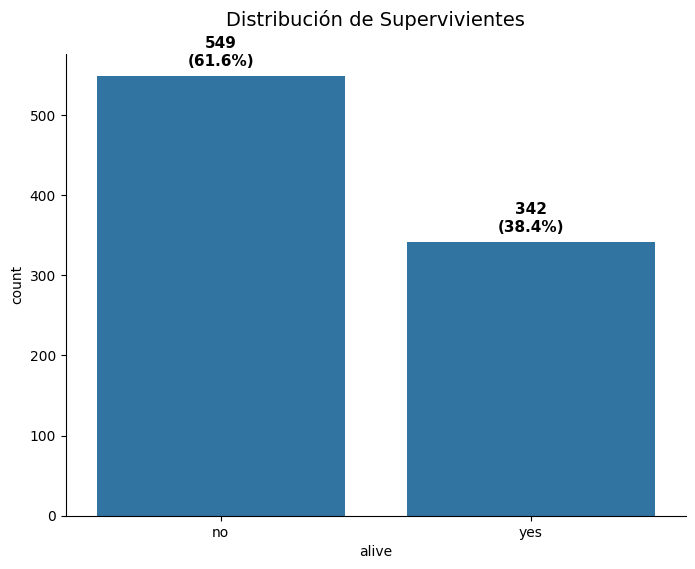

In [115]:
# Ejemplo de gráfico para variable categórica (Supervivientes)

plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df_titanic_edit, x='alive')

total = len(df_titanic_edit)

for p in ax.patches:
  numero_absoluto = p.get_height() # Altura representa el número absoluto de pasajeros
  percent = (numero_absoluto / total) * 100 # Calculamos el porcentaje
  text_etiqueta = f'{numero_absoluto:.0f}\n({percent:.1f}%)' # Texto combinado

  ax.annotate(text_etiqueta,
              (p.get_x() + p.get_width() / 2., numero_absoluto),
              ha='center', va='bottom',
              xytext=(0, 5),
              textcoords='offset points',
              fontsize=11, fontweight='bold')

plt.title('Distribución de Supervivientes', pad=20, fontsize=14)

sns.despine()
plt.show()

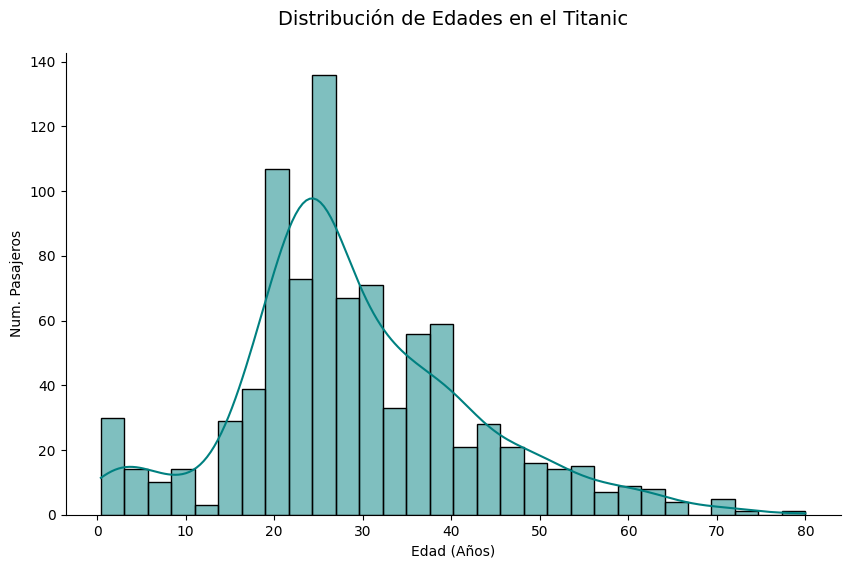

In [116]:
# Ejemplo de gráfico para variable numérica (Edades)

plt.figure(figsize=(10, 6))

# Histograma
# bins=30: 30 franjas
# kde=True: línia de tendencia
sns.histplot(data=df_titanic_edit, x='age', bins=30, kde=True, color='teal')

plt.title('Distribución de Edades en el Titanic', pad=20, fontsize=14)
plt.xlabel('Edad (Años)')
plt.ylabel('Num. Pasajeros')

sns.despine()
plt.show()

### Exportación de Gráficos

In [117]:
# Función para crear y exportar un gráfico para cada columna del df Titanic

def graficos_titanic(df, columna):
  """
  Crea y exporta (PNG) un gráfico para cada columna del DataFrame.
  El tipo de gráfico depende de si la columna es categórica o numérica.
  """

  if df is None or columna not in df.columns:
    print("Error creando gráficos. Dataframe o Columna no se encuentra")
    return None

  try:
    dicc_titles = {
      'sex': 'Género',
      'age': 'Edad',
      'fare': 'Precio del billete',
      'class': 'Clase',
      'embark_town': 'Puerto de embarque',
      'alive': 'Supervivientes',
      'family_size': 'Núm. Familiares'}

    nombre_fichero = f'grafic_titanic_{columna}.png'

    if df[columna].dtype == 'object' or str(df[columna].dtype) == 'category':
      # Gráficos Categóricos
      plt.figure(figsize=(8, 6))
      ax = sns.countplot(data=df, x=columna)
      total = len(df)

      for p in ax.patches:
        numero_absoluto = p.get_height()
        if numero_absoluto > 0:
          percent = (numero_absoluto / total) * 100
          texto_etiqueta = f'{numero_absoluto:.0f}\n({percent:.1f}%)'
          ax.annotate(texto_etiqueta,
            (p.get_x() + p.get_width() / 2., numero_absoluto),
            ha='center', va='bottom',
            xytext=(0, 5),
            textcoords='offset points',
            fontsize=11, fontweight='bold')
      plt.title(dicc_titles[columna], pad=20, fontsize=14)
      plt.ylabel('Núm. Pasajeros')
      sns.despine()

      # Exportar y mostrar gráfico
      plt.savefig(nombre_fichero, dpi=300, bbox_inches='tight')
      print(f"Gràfico exportado correctamente como '{nombre_fichero}'")
      plt.show()

    elif df[columna].dtype in ['float64', 'int64']:
      # Gráficos Numéricos
      plt.figure(figsize=(10, 6))

      # Condiciones específicas para cada columna
      if columna == 'family_size':
        sns.histplot(data=df, x=columna, discrete=True, color='coral')
      elif columna == 'age':
        sns.histplot(data=df, x=columna, bins=30, kde=True, color='teal')
      elif columna == 'fare':
        sns.histplot(data=df, x=columna, bins=40, kde=True, color='purple')

      plt.title(dicc_titles[columna], pad=20, fontsize=14)
      plt.ylabel('Núm. Pasajeros')
      sns.despine()

      # Exportar y mostrar gráfico
      plt.savefig(nombre_fichero, dpi=300, bbox_inches='tight')
      print(f"Gràfico exportado correctamente como '{nombre_fichero}'")
      plt.show()

  except Exception as e:
    print(f"Se ha producido un error: {e}")
    return None

Gràfico exportado correctamente como 'grafic_titanic_class.png'


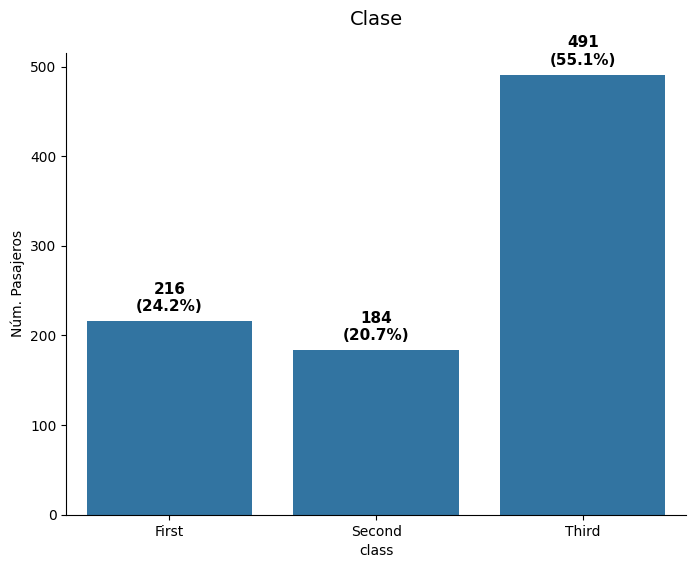

In [118]:
graficos_titanic(df_titanic_edit, 'class')

Gràfico exportado correctamente como 'grafic_titanic_age.png'


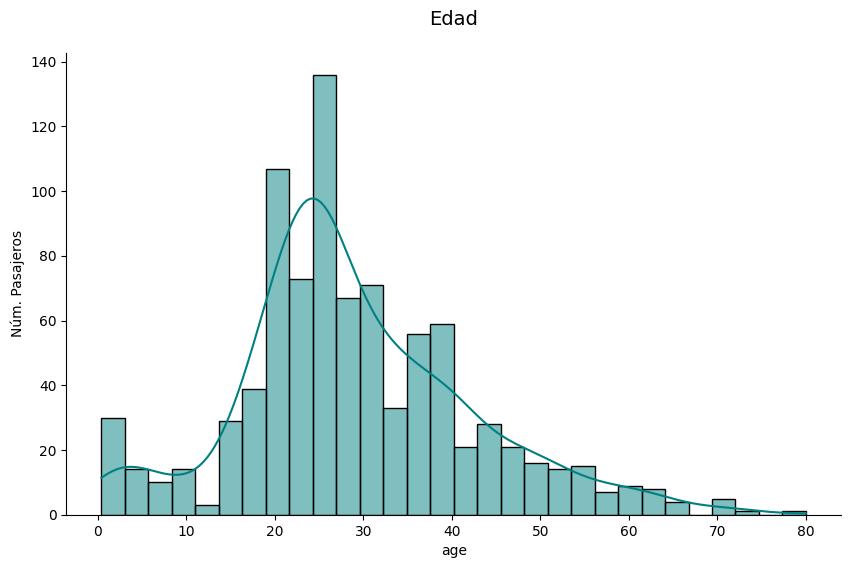

In [119]:
graficos_titanic(df_titanic_edit, 'age')

## 3.2: Optimización de Rutas

A partir de una matriz de distancias entre ciudades, vamos a construir una función que calcula los quilómtros recorridos para ir de una ciudad de origen a una de destino.

In [120]:
# Importación del fichero de Distancias

fichero_distancias = 'matriu_distancies.xlsx'
df_distancias = pd.read_excel(fichero_distancias, sheet_name='Distancia (kilómetros)', header=0, index_col=0)

display(df_distancias)

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Palma,Las Palmas de Gran Canaria,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,206.0,2175.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,260.0,1874.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,791.0,1355.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,377.0,2001.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,695.0,1406.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,372.0,1723.0,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Palma,206.0,260.0,791.0,377.0,695.0,372.0,NaN,2093.0,621.0,303.0,671.0,664.0,1000.0,820.0,204.0
Las Palmas de Gran Canaria,2175.0,1874.0,1355.0,2001.0,1406.0,1723.0,2093.0,NaN,2022.0,1792.0,1470.0,1790.0,1682.0,1925.0,2168.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,621.0,2022.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,303.0,1792.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0


In [121]:
# Elimino las filas y columnas referentes a Palma y Las Palmas de Gran Canaria
df_distancias = df_distancias.drop(index=['Palma', 'Las Palmas de Gran Canaria'])
df_distancias = df_distancias.drop(columns=['Palma', 'Las Palmas de Gran Canaria'])

display(df_distancias.columns)

Index(['Barcelona', 'Valencia', 'Sevilla', 'Zaragoza', 'Málaga', 'Murcia',
       'Bilbao', 'Alicante', 'Córdoba', 'Valladolid', 'Vigo', 'Gijón',
       'Hospitalet de Llobregat'],
      dtype='object')

In [122]:
# Ver distancia entre ciudades
print(df_distancias.loc['Barcelona', 'Bilbao'])

469.0


In [123]:
# Tabla con las ciudades más próximas
df_proximas_kms = pd.DataFrame({
    'Ciudad_Proxima': df_distancias.idxmin(axis=1),
    'Distancia_Km': df_distancias.min(axis=1)
})

display(df_proximas_kms)

,Ciudad_Proxima,Distancia_Km
Barcelona,Hospitalet de Llobregat,7.0
Valencia,Alicante,125.0
Sevilla,Córdoba,121.0
Zaragoza,Valencia,246.0
Málaga,Córdoba,133.0
Murcia,Alicante,69.0
Bilbao,Gijón,223.0
Alicante,Murcia,69.0
Córdoba,Sevilla,121.0
Valladolid,Gijón,224.0


In [124]:
# Tabla con el ranking de ciudades más próximas para cada ciudad
df_proximas_ranking = (
    df_distancias
    .rank(axis=1)       # Calcula la posición para cada fila ignorando los NaN
    .fillna(0)          # Sustituye los NaN (la propia ciudad) por un 0
    .astype(int)        # Convierte los números decimales (1.0) a enteros (1)
)

display(df_proximas_ranking)

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,0,3,11,2,10,6,5,4,9,7,12,8,1
Valencia,5,0,10,3,8,2,9,1,6,7,12,11,4
Sevilla,12,6,0,8,2,3,10,5,1,4,7,9,11
Zaragoza,4,1,11,0,10,7,1,6,9,5,12,8,3
Málaga,12,5,2,7,0,3,9,4,1,6,8,11,10
Murcia,8,2,6,5,4,0,10,1,3,9,12,11,7
Bilbao,5,6,11,3,12,9,0,8,10,2,7,1,4
Alicante,7,2,8,3,5,1,10,0,4,9,12,11,6
Córdoba,12,6,1,7,2,3,9,4,0,5,8,10,11
Valladolid,12,6,7,3,10,8,2,9,5,0,4,1,11


In [125]:
# Función para calcular la ruta entre dos ciudades (origen y destino)

def calcular_ruta(origen, destino):

  tabla_distancias = df_distancias.copy()
  tabla_proximas = df_proximas_ranking.copy()

  if origen not in tabla_distancias.index or destino not in tabla_distancias.columns:
    return None, None

  kms_totales = 0.0
  ruta = [(origen, kms_totales)]

  ciudades_posibles = tabla_proximas.index.tolist()
  ciudad_actual = origen
  ciudades_posibles.remove(ciudad_actual)

  while ciudad_actual != destino:
    proxima_ciudad = tabla_proximas.loc[ciudad_actual, ciudades_posibles].idxmin()
    ruta.append((proxima_ciudad, float(tabla_distancias.loc[ciudad_actual, proxima_ciudad])))
    kms_totales += float(tabla_distancias.loc[ciudad_actual, proxima_ciudad])
    ciudades_posibles.remove(proxima_ciudad)
    ciudad_actual = proxima_ciudad

  print(f"La ruta entre {origen} y {destino} tiene los siguientes pasos:")
  for ciudad, kms in ruta:
    print(f"- {ciudad}: {kms} kms")
  print(f"\nLa distancia total recorrida es de {kms_totales} kms.\n")

  return ruta, kms_totales

In [126]:
calcular_ruta('Barcelona', 'Vigo')

La ruta entre Barcelona y Vigo tiene los siguientes pasos:
- Barcelona: 0.0 kms
- Hospitalet de Llobregat: 7.0 kms
- Zaragoza: 250.0 kms
- Valencia: 246.0 kms
- Alicante: 125.0 kms
- Murcia: 69.0 kms
- Córdoba: 320.0 kms
- Sevilla: 121.0 kms
- Málaga: 158.0 kms
- Valladolid: 549.0 kms
- Gijón: 224.0 kms
- Bilbao: 223.0 kms
- Vigo: 486.0 kms

La distancia total recorrida es de 2778.0 kms.



([('Barcelona', 0.0),
  ('Hospitalet de Llobregat', 7.0),
  ('Zaragoza', 250.0),
  ('Valencia', 246.0),
  ('Alicante', 125.0),
  ('Murcia', 69.0),
  ('Córdoba', 320.0),
  ('Sevilla', 121.0),
  ('Málaga', 158.0),
  ('Valladolid', 549.0),
  ('Gijón', 224.0),
  ('Bilbao', 223.0),
  ('Vigo', 486.0)],
 2778.0)